<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L1_RNNs_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=jPqmZSfr9_w) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P01.pdf)

In [1]:
# Week 7, Lecture 1: RNN's Intro
from IPython.display import HTML, display

VIDEO_ID = "jPqmZSfr9_w"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 1: Recurrent Neural Networks: An Introduction

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.1 Introduction to RNNs**.

Every network so far took an input of fixed size and treated each input as independent of the last. This notebook builds the model that drops both assumptions: a recurrence with an internal state and one set of weights reused at every time step. It draws the computational graphs the slides use to explain backpropagation, trains a many-to-one sequence classifier and a character-level language model, and measures each claim the slides make along the way.

**What you will learn**
- Why **sequence learning problems** (dependent inputs, variable length, the same task at every position) break the feedforward assumption, and what the deck's example tasks look like as tensor shapes.
- The **recurrence** $h_t = f_{UW}(x_t, h_{t-1})$ and the simple RNN $h_t = \tanh(Ux_t + Wh_{t-1})$, $y_t = \mathrm{softmax}(Vh_t)$, built from scratch and matched to `nn.RNN`.
- **Weight sharing across time**: the parameter count does not depend on the sequence length $T$, measured against an MLP that reads the whole sequence at once.
- **Computational graphs**: forward evaluation, local derivatives on edges, and the rule that a derivative is a **sum over paths** of products of edge derivatives, coded from scratch and checked against `torch.autograd`.
- The **unrolled RNN graph** for the one-to-many, many-to-one and many-to-many shapes, and why the gradient of the summed loss with respect to the shared $W$ is a sum over time steps.
- A **many-to-one classifier** on a synthetic task where order matters, with accuracy measured against sequence length and hidden size.
- A **character-level language model** with **temperature sampling**, and the slide's homework on stacked RNNs and on "morphing the state too much", answered with measurements.

**Contents**

1. Sequence learning problems
2. Recurrent neural networks: variants
3. The recurrent neural network
4. Computational graphs
5. The MLP as a computational graph
6. Back to RNNs: the unrolled computational graph
7. Many-to-one in practice: a sequence classifier
8. A character-level language model
9. The slide's homework, answered
10. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

Week 6 closed the convolutional part of the course: object detection with boxes, then segmentation per pixel. The deck opens with one last review question from that material, *how do you find bias in a model?* The slide's answer is to change the attribute in question and see whether the prediction changes: a model that flips its output when only an irrelevant feature moves is leaning on that feature. Every model in Weeks 3 to 6 shared two silent assumptions: the input has a **fixed size** (a $32 \times 32$ image, say) and every input is **independent** of the previous and the next one. This lecture asks what to do when neither holds, when the inputs form a sequence whose elements depend on each other and whose length is not known in advance.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100

def count_params(module):
    """Total number of parameters in an nn.Module."""
    return sum(p.numel() for p in module.parameters())

print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Sequence learning problems

A CNN for image classification takes a fixed-size input, say $32 \times 32$, and produces one label. Feed it two images in a row and the two computations are entirely independent: nothing about the first influences the second. The slides put it plainly:

> "Computations, outputs and decisions for two successive images are completely independent of each other."

Now think about text auto-completion, the running example on the slides. Three things change at once:

- successive inputs are **no longer independent**: what you typed matters for what comes next,
- the **length of the inputs and the number of predictions** you need to make are not fixed,
- the underlying model performs the **same task across all contexts** (input: a character, output: a character).

Problems with these three properties are **sequence learning problems**. Two small experiments make the feedforward assumptions concrete. First, a linear layer applied to five inputs is **order-blind**: shuffle the inputs and every output row is still there, just permuted, so the order carried no information. Second, a layer built for a sequence of one length cannot even accept a sequence of another length.

In [3]:
# A feedforward layer has no memory: shuffle the inputs and each output is unchanged.
set_seed(0)
lin = nn.Linear(4, 3, bias=False).to(device)
xs = torch.randn(5, 4, device=device)                    # five independent inputs

out_in_order = torch.stack([lin(x) for x in xs])
out_shuffled = torch.stack([lin(x) for x in xs[torch.randperm(5, device=device)]])

# Every row of the shuffled output is still a row of the original: order carried no information.
matched = sum(any(torch.allclose(a, b, atol=1e-6) for b in out_in_order) for a in out_shuffled)
print(f'rows of the shuffled output found in the original: {matched}/5')
print('a feedforward layer is order-blind: the sequence itself carries no information')

# A fixed-size model cannot accept a sequence of a different length at all.
mlp_for_4 = nn.Linear(4 * 3, 2).to(device)               # built for T = 4 tokens of dimension 3
for T in (4, 6):
    seq = torch.randn(T, 3, device=device)
    try:
        out = mlp_for_4(seq.flatten())
        print(f'T = {T}: input {tuple(seq.shape)} flattened to {tuple(seq.flatten().shape)} -> output {tuple(out.shape)}')
    except Exception as err:                             # a shape error (its exact type differs across devices)
        print(f'T = {T}: input {tuple(seq.shape)} -> {type(err).__name__}: {str(err)[:60]}...')

rows of the shuffled output found in the original: 5/5
a feedforward layer is order-blind: the sequence itself carries no information
T = 4: input (4, 3) flattened to (12,) -> output (2,)
T = 6: input (6, 3) -> RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x18 and 12x2)...


### 1.a The tasks on the slides as tensor shapes

The deck's examples are text auto-completion (the slide that introduces sequence learning problems) and, on the slide of examples, image captioning, action prediction and frame-level video classification; to these the table adds part-of-speech tagging, the standard NLP example from the CS7015 lecture the deck acknowledges. Writing each as tensors shows what "variable number of inputs and outputs" means in practice. A **character** is a one-hot vector over the vocabulary, a **word** an embedding vector, a **frame** a small image, and every task is a mapping from a stack of such things to another stack. The point to notice is that $T$ (the number of inputs) and $T'$ (the number of outputs) differ from task to task and from example to example, while the *per-position* job is always the same.

In [4]:
# Five sequence tasks as concrete tensors. Sizes are illustrative; shapes are what matter.
V_chars, D_word, n_tags, n_actions = 27, 50, 12, 10

tasks = {
    # name                   : (input tensor,                                  output tensor)
    'text auto-completion'   : (F.one_hot(torch.tensor([7, 4, 11, 11]), V_chars).float(),  # "hell" ->
                                F.one_hot(torch.tensor([4, 11, 11, 14]), V_chars).float()),  # "ello"
    'part-of-speech tagging' : (torch.randn(9, D_word),  torch.zeros(9, n_tags)),              # 9 words -> 9 tags
    'action recognition'     : (torch.randn(16, 3, 32, 32), torch.zeros(n_actions)),           # 16 frames -> 1 label
    'frame classification'   : (torch.randn(16, 3, 32, 32), torch.zeros(16, n_actions)),       # 16 frames -> 16 labels
    'image captioning'       : (torch.randn(3, 32, 32),  torch.zeros(6, V_chars)),             # 1 image -> 6 tokens
}

print(f'{"task":24s} {"input shape":>18s} {"output shape":>14s}   inputs -> outputs')
for name, (x, y) in tasks.items():
    n_in = x.shape[0] if x.dim() != 3 else 1        # a single image is one input
    n_out = y.shape[0] if y.dim() == 2 else 1
    print(f'{name:24s} {str(tuple(x.shape)):>18s} {str(tuple(y.shape)):>14s}   {n_in:2d} -> {n_out}')
print('\nthe per-position job never changes (character -> character, word -> tag, frame -> state or label),')
print('but the number of inputs and outputs does; no fixed-size layer fits all rows of this table')

task                            input shape   output shape   inputs -> outputs
text auto-completion                (4, 27)        (4, 27)    4 -> 4
part-of-speech tagging              (9, 50)        (9, 12)    9 -> 9
action recognition          (16, 3, 32, 32)          (10,)   16 -> 1
frame classification        (16, 3, 32, 32)       (16, 10)   16 -> 16
image captioning                (3, 32, 32)        (6, 27)    1 -> 6

the per-position job never changes (character -> character, word -> tag, frame -> state or label),
but the number of inputs and outputs does; no fixed-size layer fits all rows of this table


## 2. Recurrent neural networks: variants

The slides borrow the classic diagram from Stanford's CS231n (Lecture 10, Fei-Fei Li): five ways to wire inputs (red), hidden states (green) and outputs (blue) together. What differs between them is only *how many inputs come in* and *where outputs are read*; the green recurrence in the middle is the same box repeated.

| Variant | Inputs | Outputs | Vision example |
|---|---|---|---|
| one to one | 1 | 1 | ordinary image classification, no recurrence needed |
| one to many | 1 | many | **image captioning**: one image, a sequence of words |
| many to one | many | 1 | **action recognition**: a sequence of frames, one label |
| many to many (staggered) | many | many | **video captioning** or translation: read everything, then write |
| many to many (aligned) | many | many | **frame-level video classification**: a label per frame |

The slide after the diagrams asks how to model such tasks and gives three requirements, ending with a question:

> "Account for dependence between inputs. Account for variable number of inputs. Make sure that function executed at each time step is the same. Why?"

The answer to the "why" is the whole trick of this lecture. If the function at step $t$ were different from the function at step $t+1$, the model would need a new set of weights for every position, the number of weights would grow with $T$, and a model trained on sequences of length 10 would have no weights at all for position 11. Sharing one function across time gives a model of fixed size that reads sequences of any length and, because the same job is done at every position, the training signal from every position improves the same weights.

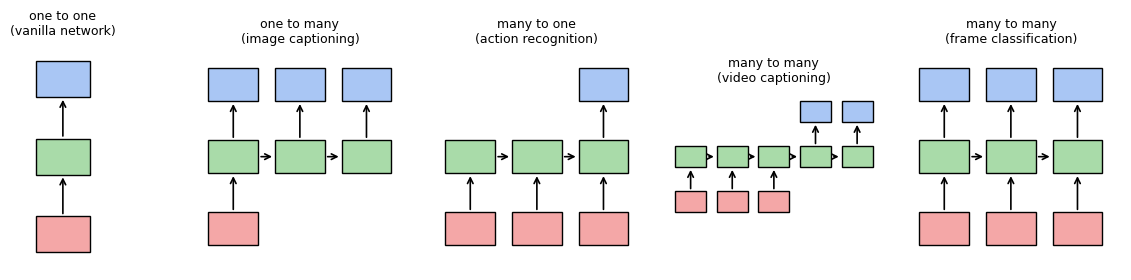

In [5]:
# Drawing helpers used throughout: coloured boxes joined by arrows, in the CS231n style.
RED, GREEN, BLUE, YELLOW, GREY = '#f4a7a7', '#a9dba9', '#a9c6f4', '#f7e6a3', '#e6e6e6'

def box(ax, x, y, text, color=GREY, w=0.9, h=0.6, fs=9):
    """A labelled box centred at (x, y)."""
    ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, fc=color, ec='k', lw=1, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, zorder=3)

def arrow(ax, p, q, label=None, box_w=0.9, box_h=0.6, ls='-', fs=8, color='k', label_dx=0.0, label_dy=0.0):
    """An arrow from the edge of the box at p to the edge of the box at q, optionally labelled."""
    p, q = np.array(p, float), np.array(q, float)
    d = q - p
    def trim(t):   # how far along d the box boundary lies
        tx = (box_w / 2) / abs(d[0]) if d[0] != 0 else np.inf
        ty = (box_h / 2) / abs(d[1]) if d[1] != 0 else np.inf
        return min(tx, ty)
    s, e = p + d * trim(1), q - d * trim(1)
    ax.annotate('', xy=e, xytext=s, arrowprops=dict(arrowstyle='->', lw=1.2, ls=ls, color=color), zorder=1)
    if label:
        m = (s + e) / 2
        ax.text(m[0] + label_dx, m[1] + label_dy, label, fontsize=fs, ha='center', va='center',
                bbox=dict(fc='white', ec='none', pad=0.5), zorder=4)

def draw_variant(ax, n_in, n_out, staggered=False, title=''):
    """One of the five CS231n diagrams: inputs (red) below, hidden (green) middle, outputs (blue) above."""
    n_h = n_in + (n_out if staggered else 0)
    if not staggered:
        n_h = max(n_in, n_out)
    xs = np.arange(n_h) * 1.2
    for i, x in enumerate(xs):
        box(ax, x, 0, '', GREEN)
        if i > 0:
            arrow(ax, (xs[i - 1], 0), (x, 0))
    for i in range(n_in):
        box(ax, xs[i], -1.3, '', RED); arrow(ax, (xs[i], -1.3), (xs[i], 0))
    out_pos = xs[n_h - n_out:] if not staggered else xs[n_in:]
    if n_out == 1 and not staggered:
        out_pos = xs[-1:]
    for x in out_pos:
        box(ax, x, 1.3, '', BLUE); arrow(ax, (x, 0), (x, 1.3))
    ax.set_xlim(-0.8, xs[-1] + 0.8); ax.set_ylim(-1.9, 1.9)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title, fontsize=9)

fig, axes = plt.subplots(1, 5, figsize=(12, 2.9))
draw_variant(axes[0], 1, 1, title='one to one\n(vanilla network)')
draw_variant(axes[1], 1, 3, title='one to many\n(image captioning)')
draw_variant(axes[2], 3, 1, title='many to one\n(action recognition)')
draw_variant(axes[3], 3, 2, staggered=True, title='many to many\n(video captioning)')
draw_variant(axes[4], 3, 3, title='many to many\n(frame classification)')
plt.tight_layout(); plt.show()

## 3. The recurrent neural network

The fix for all three requirements is an **internal state** that is updated as the sequence is processed. The slide writes it as

$$h_t = f_{UW}(x_t,\, h_{t-1})$$

where $h_t$ is the new state, $h_{t-1}$ the old state, $x_t$ the input at this step, and $f_{UW}$ a function with parameters $U$ and $W$. The **same function with the same parameters** is applied at every time step; that is the sentence the slides print in red. Drawn folded, the network is one box with an arrow looping back into itself; drawn **unfolded** in time, it is a chain of $T$ copies of that box, every copy sharing $U$, $W$ and $V$.

The **simple RNN** (also called *vanilla* or *Elman* RNN) takes the state to be a single hidden vector and uses a $\tanh$:

$$h_t = \tanh\!\left(U x_t + W h_{t-1}\right), \qquad y_t = \mathrm{softmax}\!\left(V h_t\right)$$

with $U \in \mathbb{R}^{H \times D}$ mapping the input into the state, $W \in \mathbb{R}^{H \times H}$ mapping the old state into the new one, and $V \in \mathbb{R}^{C \times H}$ reading an output from the state. The slide writes no bias terms and neither do we.

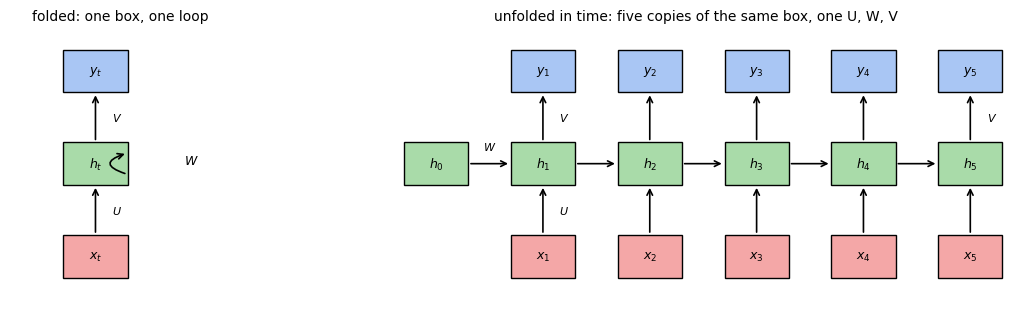

In [6]:
# The folded network and its unfolding in time. draw_unrolled is reused for the graphs in section 6.
def draw_unrolled(ax, T, outputs='all', losses=False, title='', inputs='all', h0=True):
    """The RNN unrolled for T steps. outputs: 'all' | 'last' | 'pool' (one y reading every h_t) | 'none';
    inputs: 'all' | 'first'."""
    dx = 1.5
    xs = np.arange(1, T + 1) * dx
    if h0:
        box(ax, 0, 0, '$h_0$', GREEN)
    for t, x in zip(range(1, T + 1), xs):
        box(ax, x, 0, f'$h_{{{t}}}$', GREEN)
        if h0 or t > 1:
            arrow(ax, (x - dx, 0), (x, 0), label='$W$' if t == 1 else None, label_dy=0.25)
        if inputs == 'all' or t == 1:
            box(ax, x, -1.3, f'$x_{{{t}}}$', RED)
            arrow(ax, (x, -1.3), (x, 0), label='$U$' if t == 1 else None, label_dx=0.3)
        read = (outputs == 'all') or (outputs == 'last' and t == T)
        if read:
            box(ax, x, 1.3, f'$y_{{{t}}}$', BLUE)
            arrow(ax, (x, 0), (x, 1.3), label='$V$' if t in (1, T) else None, label_dx=0.3)
            if losses and outputs == 'all':
                box(ax, x, 2.5, f'$L_{{{t}}}$', YELLOW)
                arrow(ax, (x, 1.3), (x, 2.5))
    if outputs == 'pool':                       # the slide's second many-to-one build: y reads every h_t
        xc = xs.mean()
        box(ax, xc, 1.5, '$y$', BLUE)
        for x in xs:
            arrow(ax, (x, 0), (xc, 1.5), label='$V$' if x == xs[0] else None, label_dx=-0.25, label_dy=0.2)
        if losses:
            box(ax, xc, 2.7, '$L$', YELLOW); arrow(ax, (xc, 1.5), (xc, 2.7))
    elif losses:
        xL = xs[-1] + dx if outputs == 'all' else xs[-1]
        yL = 3.7 if outputs == 'all' else 2.5
        box(ax, xL, yL, '$L$', YELLOW)
        if outputs == 'all':
            for x in xs:
                arrow(ax, (x, 2.5), (xL, yL))
        else:
            arrow(ax, (xs[-1], 1.3), (xL, yL))
    lo = -0.8 if h0 else xs[0] - 0.8
    ax.set_xlim(lo, xs[-1] + (dx + 0.6 if losses and outputs == 'all' else 0.6))
    ax.set_ylim(-1.9, (4.3 if losses and outputs == 'all' else 3.1 if losses else 1.9))
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title, fontsize=10)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 3.2), gridspec_kw={'width_ratios': [1, 3.2]})
# folded: one box with a loop
box(a0, 0, 0, '$h_t$', GREEN); box(a0, 0, -1.3, '$x_t$', RED); box(a0, 0, 1.3, '$y_t$', BLUE)
arrow(a0, (0, -1.3), (0, 0), label='$U$', label_dx=0.3); arrow(a0, (0, 0), (0, 1.3), label='$V$', label_dx=0.3)
a0.annotate('', xy=(0.45, 0.15), xytext=(0.45, -0.15),
            arrowprops=dict(arrowstyle='->', lw=1.2, connectionstyle='arc3,rad=-1.6'))
a0.text(1.35, 0, '$W$', fontsize=9, ha='center')
a0.set_xlim(-1.2, 1.9); a0.set_ylim(-1.9, 1.9); a0.set_aspect('equal'); a0.axis('off')
a0.set_title('folded: one box, one loop', fontsize=10)
draw_unrolled(a1, 5, title='unfolded in time: five copies of the same box, one U, W, V')
plt.tight_layout(); plt.show()

### 3.a The recurrence from scratch

The loop below is the whole model. $U$, $W$ and $V$ are created once and used at every step; the only thing that changes from step to step is the state $h$ that is carried forward.

In [7]:
# The recurrence, written out as a loop. Note U, W, V are created once and reused.
D, H, C = 4, 3, 4                            # input dim, hidden dim, output dim
set_seed(0)
U = torch.randn(H, D, device=device) * 0.3   # input -> hidden
W = torch.randn(H, H, device=device) * 0.3   # hidden -> hidden
V = torch.randn(C, H, device=device) * 0.3   # hidden -> output

def rnn_forward(xs, U, W, V, h0=None):
    """Simple RNN: h_t = tanh(U x_t + W h_{t-1}), y_t = softmax(V h_t), for xs of shape (T, D).
    Returns the hidden states (T, H) and the output distributions (T, C)."""
    h = torch.zeros(U.shape[0], device=xs.device) if h0 is None else h0
    hs, ys = [], []
    for x in xs:
        h = torch.tanh(U @ x + W @ h)        # the same U, W at every step
        hs.append(h)
        ys.append(torch.softmax(V @ h, dim=0))
    return torch.stack(hs), torch.stack(ys)

xs = torch.randn(6, D, device=device)
hs, ys = rnn_forward(xs, U, W, V)
print(f'input  {tuple(xs.shape)}  ->  hidden {tuple(hs.shape)}  ->  output {tuple(ys.shape)}')
print(f'every output row sums to 1: {torch.allclose(ys.sum(1), torch.ones(6, device=device))}')
print(f'h_1 = {hs[0].tolist()}')
print(f'h_6 = {hs[5].tolist()}   (a function of all six inputs, through the state)')

input  (6, 4)  ->  hidden (6, 3)  ->  output (6, 4)
every output row sums to 1: True
h_1 = [-0.49516382813453674, -0.5147063732147217, 0.1108645424246788]
h_6 = [0.17750029265880585, -0.06629106402397156, -0.36391058564186096]   (a function of all six inputs, through the state)


### 3.b Weight sharing: the parameter count does not depend on $T$

Because one $U$, $W$, $V$ serve every step, the number of weights is $HD + H^2 + CH = 12 + 9 + 12 = 33$ whether the sequence has 5 elements or 500. The natural alternative, a feedforward network that reads the whole sequence at once by concatenating the $T$ inputs into one vector of length $TD$, needs a first layer of size $TD \times H$, so its parameter count **grows linearly with $T$** and it has to be rebuilt for every new length. The cell measures both.

  T =   5  ->    5 hidden states, still 33 parameters
  T =  50  ->   50 hidden states, still 33 parameters
  T = 500  ->  500 hidden states, still 33 parameters

U (3, 4) + W (3, 3) + V (4, 3) = 12 + 9 + 12 = 33 weights, for any T


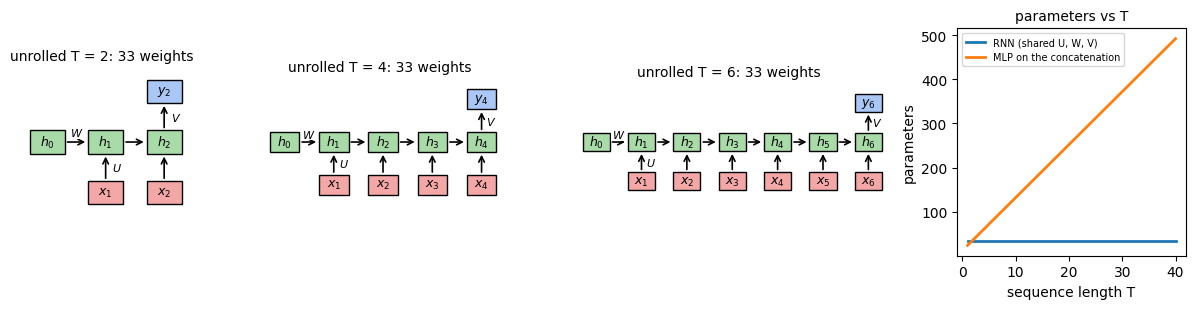

MLP on the concatenation: T = 5 -> 72 weights, T = 50 -> 612, T = 500 -> 6012


In [8]:
# Weight sharing means the parameter count does not depend on the sequence length.
n_rnn = U.numel() + W.numel() + V.numel()
for T in (5, 50, 500):
    hs_T, _ = rnn_forward(torch.randn(T, D, device=device), U, W, V)
    print(f'  T = {T:3d}  ->  {hs_T.shape[0]:3d} hidden states, still {n_rnn} parameters')
print(f'\nU {tuple(U.shape)} + W {tuple(W.shape)} + V {tuple(V.shape)} = '
      f'{U.numel()} + {W.numel()} + {V.numel()} = {n_rnn} weights, for any T')

def mlp_on_concat_params(T, D=D, H=H, C=C):
    """Weights of a one-hidden-layer MLP that reads the T inputs concatenated into one vector (no biases)."""
    return T * D * H + H * C

Ts = np.arange(1, 41)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), gridspec_kw={'width_ratios': [1.2, 1.7, 2.2, 1.6]})
for ax, T in zip(axes[:3], (2, 4, 6)):
    draw_unrolled(ax, T, outputs='last', title=f'unrolled T = {T}: {n_rnn} weights')
axes[3].plot(Ts, [n_rnn] * len(Ts), lw=2, label='RNN (shared U, W, V)')
axes[3].plot(Ts, [mlp_on_concat_params(T) for T in Ts], lw=2, label='MLP on the concatenation')
axes[3].set_xlabel('sequence length T'); axes[3].set_ylabel('parameters'); axes[3].legend(fontsize=7)
axes[3].set_title('parameters vs T', fontsize=10)
plt.tight_layout(); plt.show()
print(f'MLP on the concatenation: T = 5 -> {mlp_on_concat_params(5)} weights, T = 50 -> {mlp_on_concat_params(50)}, '
      f'T = 500 -> {mlp_on_concat_params(500)}')

### Widget 1: unroll length versus parameter count

Drag `T`. The unrolled chain grows one green box per step and the hidden-state count grows with it, but the weight count in the title stays at 33, while the MLP that would read the same sequence at once needs $12T + 12$ weights.

In [9]:
def unroll_widget(T=4):
    fig, ax = plt.subplots(figsize=(min(12, 1.6 * T + 2), 3.0))
    draw_unrolled(ax, T, outputs='last',
                  title=f'T = {T}: {T} hidden states, {n_rnn} RNN weights  |  MLP on the concatenation: '
                        f'{mlp_on_concat_params(T)} weights')
    plt.tight_layout(); plt.show()

interact(unroll_widget, T=IntSlider(min=1, max=12, step=1, value=4, continuous_update=False));

interactive(children=(IntSlider(value=4, continuous_update=False, description='T', max=12, min=1), Output()), …

### 3.c The idiomatic version: `nn.RNN`

PyTorch's `nn.RNN` computes exactly this recurrence (with biases, which we switch off to match the slide) for a whole batch at once and returns every hidden state plus the final one. Copy our $U$ and $W$ into it and the two agree to floating-point precision.

In [10]:
# Our loop == nn.RNN. The slides write no bias terms, so build the module with bias=False.
ref = nn.RNN(input_size=D, hidden_size=H, nonlinearity='tanh', bias=False, batch_first=True).to(device)
with torch.no_grad():
    ref.weight_ih_l0.copy_(U)                # nn.RNN's names: weight_ih is our U, weight_hh is our W
    ref.weight_hh_l0.copy_(W)

xs_test = torch.randn(7, D, device=device)
ours, _ = rnn_forward(xs_test, U, W, V)
theirs, h_last = ref(xs_test[None])          # batch of one: (1, T, D) -> (1, T, H), (1, 1, H)
assert torch.allclose(ours, theirs[0], atol=1e-6), 'hand-written loop disagrees with nn.RNN'
assert torch.allclose(ours[-1], h_last[0, 0], atol=1e-6), 'final state disagrees'
print(f'loop vs nn.RNN over {xs_test.shape[0]} steps: max |difference| = {(ours - theirs[0]).abs().max().item():.2e}')
print(f'nn.RNN parameters: {[(n, tuple(p.shape)) for n, p in ref.named_parameters()]}')
print(f'nn.RNN returns all states {tuple(theirs.shape)} and the last state {tuple(h_last.shape)}')

loop vs nn.RNN over 7 steps: max |difference| = 5.96e-08
nn.RNN parameters: [('weight_ih_l0', (3, 4)), ('weight_hh_l0', (3, 3))]
nn.RNN returns all states (1, 7, 3) and the last state (1, 1, 3)


### 3.d The four shapes as tensor traces

The same recurrence supports every variant of section 2. The differences are entirely in *where you read outputs from* and *what you feed in*. For the vision tasks the raw input is an image or a frame, so a small encoder (here a single convolution and a linear layer, standing in for a CNN) turns each frame into the vector $x_t$ that the recurrence expects: **action recognition** encodes every frame and reads one output at the end, **captioning** encodes one image, feeds it as $x_1$ and reads an output at every step.

In [11]:
# Each shape as a tensor trace, using the same recurrence underneath.
T = 6
hs, ys = rnn_forward(torch.randn(T, D, device=device), U, W, V)
print(f'many-to-many (aligned) : {T} inputs -> {ys.shape[0]} outputs   {tuple(ys.shape)}')
print(f'many-to-one            : {T} inputs -> 1 output    {tuple(ys[-1].shape)}  (read the last state only)')

# one-to-many: one real input, then zeros (or the previous output) at later steps
x0 = torch.randn(D, device=device)
seq = torch.cat([x0[None, :], torch.zeros(T - 1, D, device=device)])
_, ys_om = rnn_forward(seq, U, W, V)
print(f'one-to-many            : 1 input  -> {ys_om.shape[0]} outputs   {tuple(ys_om.shape)}')

losses = torch.stack([-torch.log(y[0] + 1e-9) for y in ys])     # a per-step loss
print(f'\nper-step losses {tuple(losses.shape)} aggregate into one scalar L = {losses.sum():.4f}')

# The vision versions: a tiny frame encoder produces the x_t that the recurrence reads.
set_seed(0)
encoder = nn.Sequential(nn.Conv2d(3, 8, 3, stride=2, padding=1), nn.ReLU(),
                        nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(8, D)).to(device)
frames = torch.randn(16, 3, 32, 32, device=device)             # 16 frames of a clip
x_frames = encoder(frames)                                     # (16, D): one x_t per frame
_, y_action = rnn_forward(x_frames, U, W, V)
print(f'\naction recognition     : frames {tuple(frames.shape)} -> x {tuple(x_frames.shape)} -> label scores {tuple(y_action[-1].shape)}')
image = torch.randn(1, 3, 32, 32, device=device)
x_img = encoder(image)                                         # (1, D): the image is x_1
_, y_caption = rnn_forward(torch.cat([x_img, torch.zeros(5, D, device=device)]), U, W, V)
print(f'image captioning       : image {tuple(image.shape)}  -> x {tuple(x_img.shape)}  -> 6 token scores {tuple(y_caption.shape)}')

many-to-many (aligned) : 6 inputs -> 6 outputs   (6, 4)
many-to-one            : 6 inputs -> 1 output    (4,)  (read the last state only)
one-to-many            : 1 input  -> 6 outputs   (6, 4)

per-step losses (6,) aggregate into one scalar L = 8.1015

action recognition     : frames (16, 3, 32, 32) -> x (16, 4) -> label scores (4,)
image captioning       : image (1, 3, 32, 32)  -> x (1, 4)  -> 6 token scores (6, 4)


## 4. Computational graphs

Backpropagation through an unrolled RNN is easier to think about as a graph, so the slides pause for a review. A **computational graph** is a directed graph whose nodes are **operations** and **variables**; the values that flow along the edges are **tensors** (multi-dimensional arrays, which subsume scalars, vectors and matrices). The graph can be instantiated for two kinds of computation, **forward** (evaluate the expression) and **backward** (differentiate it).

### 4.a Creating and evaluating an expression

The slide's example, from Christopher Olah's essay on backpropagation, is

$$e = (a + b) * (b + 1),$$

three operations (two additions, one multiplication) with intermediate steps $c = a + b$, $d = b + 1$ and $e = c * d$. To evaluate, set the input variables to values and compute the nodes upward through the graph: at $a = 2$, $b = 1$ we get $c = 3$, $d = 2$ and $e = 6$.

### 4.b Computing derivatives

The key is to understand **derivatives on edges**: each edge is labelled with how much its head changes when its tail changes, for instance $\partial c / \partial a = 1$ and $\partial e / \partial c = d$. To get the derivative of one node with respect to another,

> "General rule is to sum over all possible paths from one node to other, multiplying derivatives on each edge of path together."

That is the sum rule and the product rule applied to the graph. Here $b$ reaches $e$ by two routes, through $c$ and through $d$:

$$\frac{\partial e}{\partial b} = \underbrace{1 \cdot 2}_{b \to c \to e} + \underbrace{1 \cdot 3}_{b \to d \to e} = 5, \qquad \frac{\partial e}{\partial a} = 1 \cdot 2 = 2.$$

The next cell builds a tiny scalar graph class that stores, for every node, its value, its parents and the **local derivative on each incoming edge**. Two derivative routines follow: `path_sum` enumerates every path from the source to the target and does literally what the slide says, and `backward` is reverse-mode accumulation, the efficient way to get the same numbers for every node in one sweep. Both are checked against `torch.autograd`.

In [12]:
class Node:
    """One scalar node of a computational graph.
    value: the number it holds; parents: the nodes feeding it; local[k]: d(self)/d(parents[k]),
    the derivative on the incoming edge from parents[k]."""
    def __init__(self, value, parents=(), local=(), name=''):
        self.value, self.parents, self.local, self.name = float(value), tuple(parents), tuple(local), name
        self.children = []
        for p in self.parents:
            p.children.append(self)
    def __repr__(self):
        return f'{self.name}={self.value:g}'

# Operations: each records its local derivatives at construction time (this is what autograd does too).
def add(x, y, name):   return Node(x.value + y.value, (x, y), (1.0, 1.0), name)
def mul(x, y, name):   return Node(x.value * y.value, (x, y), (y.value, x.value), name)
def add_c(x, c, name): return Node(x.value + c, (x,), (1.0,), name)
def tanh_n(x, name):
    t = math.tanh(x.value); return Node(t, (x,), (1.0 - t * t,), name)

def all_paths(src, dst):
    """Every directed path from src to dst, each as the list of local derivatives along its edges."""
    paths = []
    def walk(node, derivs):
        if node is dst:
            paths.append(derivs); return
        for child in node.children:
            for k, parent in enumerate(child.parents):     # a node used twice by one op gives two edges
                if parent is node:
                    walk(child, derivs + [child.local[k]])
    walk(src, [])
    return paths

def path_sum(dst, src):
    """The slide's rule: sum over all paths from src to dst of the product of edge derivatives."""
    return sum(math.prod(p) for p in all_paths(src, dst))

def backward(root):
    """Reverse-mode accumulation: walk from the root back to the leaves; every node adds (sum rule)
    its gradient times the local edge derivative (product rule) into each parent."""
    order, seen = [], set()
    def topo(n):
        if id(n) in seen: return
        seen.add(id(n))
        for p in n.parents: topo(p)
        order.append(n)
    topo(root)
    grads = {id(root): 1.0}
    for node in reversed(order):
        g = grads.get(id(node), 0.0)
        for p, d in zip(node.parents, node.local):
            grads[id(p)] = grads.get(id(p), 0.0) + g * d
    return {n.name: grads.get(id(n), 0.0) for n in order}

def build_expression(a_val, b_val):
    """The slide's graph e = (a + b) * (b + 1). Returns the nodes by name."""
    a, b = Node(a_val, name='a'), Node(b_val, name='b')
    c, d = add(a, b, 'c'), add_c(b, 1.0, 'd')
    e = mul(c, d, 'e')
    return dict(a=a, b=b, c=c, d=d, e=e)

g = build_expression(2.0, 1.0)
print('forward pass (a = 2, b = 1)')
print(f"  c = a + b = {g['c'].value:g}    d = b + 1 = {g['d'].value:g}    e = c * d = {g['e'].value:g}")
print('\nlocal derivatives on the edges')
for n in ('c', 'd', 'e'):
    for p, dv in zip(g[n].parents, g[n].local):
        print(f'  d{n}/d{p.name} = {dv:g}')
print('\nsum over paths from b to e')
for path in all_paths(g['b'], g['e']):
    print(f'  path with edge derivatives {path} contributes {math.prod(path):g}')
print(f"  de/db = {path_sum(g['e'], g['b']):g}     de/da = {path_sum(g['e'], g['a']):g}")
print(f"\nreverse-mode backward gives {backward(g['e'])}")

forward pass (a = 2, b = 1)
  c = a + b = 3    d = b + 1 = 2    e = c * d = 6

local derivatives on the edges
  dc/da = 1
  dc/db = 1
  dd/db = 1
  de/dc = 2
  de/dd = 3

sum over paths from b to e
  path with edge derivatives [1.0, 2.0] contributes 2
  path with edge derivatives [1.0, 3.0] contributes 3
  de/db = 5     de/da = 2

reverse-mode backward gives {'a': 2.0, 'b': 5.0, 'c': 2.0, 'd': 3.0, 'e': 1.0}


### 4.c PyTorch does the same thing

In PyTorch the graph is not declared in advance: changes are **tracked on the go during the forward pass**, which allows dynamic graph creation, and the gradients are calculated only when `backward()` is triggered. Every tensor produced by an operation carries a `grad_fn`, the backward function of that operation, and the `grad_fn`s point at each other exactly like the edges of the drawing. The cell builds the slide's expression with tensors, prints the chain of `grad_fn`s, and checks both of our derivative routines against autograd.

In [13]:
# Build the graph with tensors, then let autograd confirm the path-sum answer.
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
c = a + b
d = b + 1
e = c * d
e.backward()

print(f'  c = a + b = {c.item():.0f},  d = b + 1 = {d.item():.0f},  e = c * d = {e.item():.0f}')
print(f'  de/da = {a.grad.item():.0f}   (one path: dc/da * de/dc = 1 * 2)')
print(f'  de/db = {b.grad.item():.0f}   (two paths: 1*2 through c, plus 1*3 through d)')
assert e.item() == 6 and a.grad.item() == 2 and b.grad.item() == 5, 'path sum disagrees with autograd'

# The graph autograd built on the go: e's grad_fn points at the grad_fns of c and d.
print(f'\n  e.grad_fn = {type(e.grad_fn).__name__}')
print(f'  e.grad_fn.next_functions = {[type(f).__name__ for f, _ in e.grad_fn.next_functions]}   (the edges into c and d)')
print(f'  c.grad_fn.next_functions = {[type(f).__name__ for f, _ in c.grad_fn.next_functions]}   (the leaves a and b)')

# Our two from-scratch routines agree with autograd at a few random points.
set_seed(0)
worst = 0.0
for _ in range(5):
    av, bv = np.random.uniform(-3, 3, size=2)
    g = build_expression(av, bv)
    ta, tb = torch.tensor(av, requires_grad=True), torch.tensor(bv, requires_grad=True)
    ((ta + tb) * (tb + 1)).backward()
    ours = (path_sum(g['e'], g['a']), path_sum(g['e'], g['b']))
    rev = backward(g['e'])
    worst = max(worst, abs(ours[0] - ta.grad.item()), abs(ours[1] - tb.grad.item()),
                abs(rev['a'] - ta.grad.item()), abs(rev['b'] - tb.grad.item()))
    assert worst < 1e-5, 'path sum or reverse mode disagrees with autograd'
print(f'\n  path sum and reverse mode vs autograd over 5 random (a, b): max |difference| = {worst:.2e}')
print('  the slide arithmetic and autograd agree')

  c = a + b = 3,  d = b + 1 = 2,  e = c * d = 6
  de/da = 2   (one path: dc/da * de/dc = 1 * 2)
  de/db = 5   (two paths: 1*2 through c, plus 1*3 through d)

  e.grad_fn = MulBackward0
  e.grad_fn.next_functions = ['AddBackward0', 'AddBackward0']   (the edges into c and d)
  c.grad_fn.next_functions = ['AccumulateGrad', 'AccumulateGrad']   (the leaves a and b)

  path sum and reverse mode vs autograd over 5 random (a, b): max |difference| = 0.00e+00
  the slide arithmetic and autograd agree


### 4.d The graph, drawn

The picture the slides show is worth reproducing with the numbers on it. Each box is a node with its value; each edge carries its local derivative. The three panels evaluate the same graph at three settings of $(a, b)$, so you can watch the edge labels $\partial e/\partial c = d$ and $\partial e/\partial d = c$ change while the addition edges stay at 1.

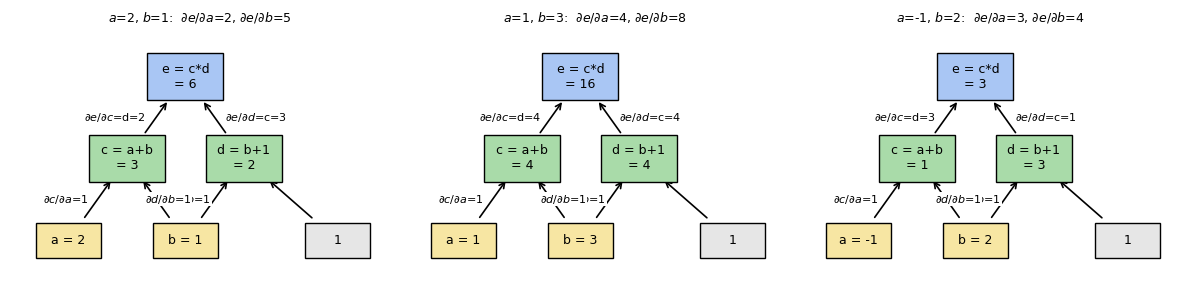

In [14]:
def draw_expression_graph(ax, a_val, b_val, title=None):
    """The graph of e = (a + b) * (b + 1) with forward values in the boxes and local derivatives on the edges."""
    g = build_expression(a_val, b_val)
    pos = dict(a=(0, 0), b=(2, 0), one=(4.6, 0), c=(1, 1.4), d=(3, 1.4), e=(2, 2.8))
    box(ax, *pos['a'], f"a = {g['a'].value:g}", YELLOW, w=1.1)
    box(ax, *pos['b'], f"b = {g['b'].value:g}", YELLOW, w=1.1)
    box(ax, *pos['one'], '1', GREY, w=1.1)
    box(ax, *pos['c'], f"c = a+b\n= {g['c'].value:g}", GREEN, w=1.3, h=0.8)
    box(ax, *pos['d'], f"d = b+1\n= {g['d'].value:g}", GREEN, w=1.3, h=0.8)
    box(ax, *pos['e'], f"e = c*d\n= {g['e'].value:g}", BLUE, w=1.3, h=0.8)
    arrow(ax, pos['a'], pos['c'], r'$\partial c/\partial a$=1', box_w=1.1, box_h=0.7, label_dx=-0.55)
    arrow(ax, pos['b'], pos['c'], r'$\partial c/\partial b$=1', box_w=1.1, box_h=0.7, label_dx=0.55)
    arrow(ax, pos['b'], pos['d'], r'$\partial d/\partial b$=1', box_w=1.1, box_h=0.7, label_dx=-0.8)
    arrow(ax, pos['one'], pos['d'], None, box_w=1.1, box_h=0.7)
    arrow(ax, pos['c'], pos['e'], rf"$\partial e/\partial c$=d={g['d'].value:g}", box_w=1.3, box_h=0.8, label_dx=-0.7)
    arrow(ax, pos['d'], pos['e'], rf"$\partial e/\partial d$=c={g['c'].value:g}", box_w=1.3, box_h=0.8, label_dx=0.7)
    de_da, de_db = path_sum(g['e'], g['a']), path_sum(g['e'], g['b'])
    ax.set_xlim(-1, 5.5); ax.set_ylim(-0.7, 3.6); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title or rf'$a$={a_val:g}, $b$={b_val:g}:  $\partial e/\partial a$={de_da:g}, $\partial e/\partial b$={de_db:g}', fontsize=9)
    return de_da, de_db

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (av, bv) in zip(axes, [(2, 1), (1, 3), (-1, 2)]):
    draw_expression_graph(ax, av, bv)
plt.tight_layout(); plt.show()

### Widget 2: the path sum under your control

Drag `a` and `b`. The two addition edges never change; the two multiplication edges carry the value of the *other* factor, $d$ on the edge from $c$ and $c$ on the edge from $d$. Check that the title's $\partial e/\partial b$ is always the sum of the two multiplication-edge labels (both paths from $b$ pass through one addition edge with derivative 1), while $\partial e/\partial a$ is just the left multiplication edge. Set $a = -b$ to make $c = 0$: then $\partial e/\partial d = 0$ and $d$ stops mattering, but $\partial e/\partial b$ is still $d$ through the other path.

In [15]:
def expression_widget(a=2.0, b=1.0):
    fig, ax = plt.subplots(figsize=(6, 3.8))
    de_da, de_db = draw_expression_graph(ax, a, b)
    plt.tight_layout(); plt.show()
    print(f'de/db by paths: 1 * {b + 1:g} (through c) + 1 * {a + b:g} (through d) = {de_db:g}')

interact(expression_widget, a=FloatSlider(min=-3, max=3, step=0.5, value=2.0),
                            b=FloatSlider(min=-3, max=3, step=0.5, value=1.0));

interactive(children=(FloatSlider(value=2.0, description='a', max=3.0, min=-3.0, step=0.5), FloatSlider(value=…

## 5. The MLP as a computational graph

The slides then draw a familiar model as a graph (after Yoav Artzi's CS5740): a one-hidden-layer MLP written as two equations,

$$h = \tanh(Wx + b), \qquad y = Vh + a,$$

whose leaves are the input $x$ and the four parameters $W$, $b$, $V$, $a$, and whose root is the output $y$. (The slide reuses the letters $W$ and $V$ for the MLP's two weight matrices; they have nothing to do with the RNN's $W$ and $V$.) The slide's graph stops at $y$. This notebook appends two more nodes so that the graph has a **scalar root whose gradients can be checked**: a softmax, $p = \mathrm{softmax}(y)$, and a cross-entropy against the true class, $L = -\log p_{\text{label}}$. One convention to declare: the slide writes column vectors, hence $Wx$; the code keeps the row-vector, batch-first convention used throughout this notebook, so a batch $x$ of shape $(n, D)$ is multiplied as $xW$ with $W$ of shape $(D, H)$, and $y = hV + a$ likewise.

Every operation is a node, every parameter is a leaf, and the loss is the root. The backward pass runs through the same nodes in reverse: each node multiplies the gradient arriving from its child by its local derivative and passes it to its parents. For this graph the local derivatives are the standard ones, and the cleanest of them is the appended softmax-plus-cross-entropy pair, whose combined local derivative is $\partial L / \partial y = p - \mathrm{onehot}(\text{label})$.

The cell draws the graph (the slide's part from $x$ to $y$, then the two appended nodes), then runs the forward and backward passes by hand on a batch of $n$ examples and checks all four parameter gradients against autograd.

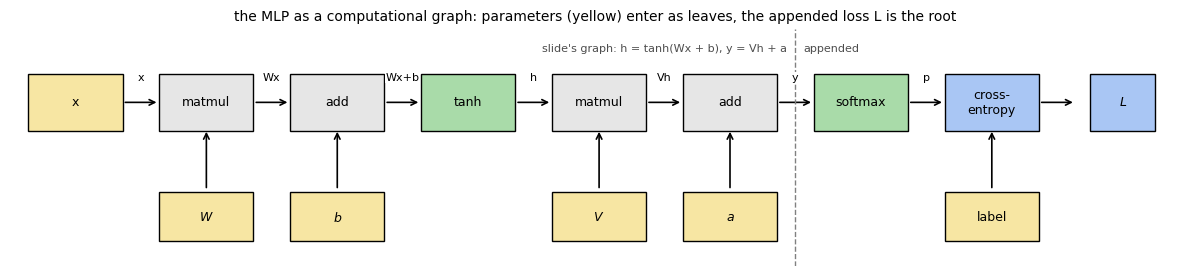

In [16]:
fig, ax = plt.subplots(figsize=(12, 2.8))
nodes = [('x', YELLOW), ('matmul', GREY), ('add', GREY), ('tanh', GREEN), ('matmul', GREY), ('add', GREY),
         ('softmax', GREEN), ('cross-\nentropy', BLUE)]
xs_pos = np.arange(len(nodes)) * 1.6
for (name, col), x in zip(nodes, xs_pos):
    box(ax, x, 0, name, col, w=1.15, h=0.7)
for x0, x1, lab in zip(xs_pos[:-1], xs_pos[1:], ['x', 'Wx', 'Wx+b', 'h', 'Vh', 'y', 'p', '']):
    arrow(ax, (x0, 0), (x1, 0), lab or None, box_w=1.15, box_h=0.7, label_dy=0.3)
for x, lab in zip(xs_pos[[1, 2, 4, 5, 7]], ['$W$', '$b$', '$V$', '$a$', 'label']):
    box(ax, x, -1.4, lab, YELLOW, w=1.15, h=0.6); arrow(ax, (x, -1.4), (x, 0), box_w=1.15, box_h=0.65)
box(ax, xs_pos[-1] + 1.6, 0, '$L$', BLUE, w=0.8, h=0.7); arrow(ax, (xs_pos[-1], 0), (xs_pos[-1] + 1.6, 0), box_w=1.15, box_h=0.7)
# The slide's graph ends at y; the two nodes to its right are appended by the notebook.
ax.axvline(xs_pos[5] + 0.8, color='0.5', ls='--', lw=1)
ax.text(xs_pos[5] + 0.7, 0.62, "slide's graph: h = tanh(Wx + b), y = Vh + a", ha='right', fontsize=8, color='0.3')
ax.text(xs_pos[5] + 0.9, 0.62, 'appended', ha='left', fontsize=8, color='0.3')
ax.set_xlim(-0.8, xs_pos[-1] + 2.3); ax.set_ylim(-2, 0.9); ax.set_aspect('equal'); ax.axis('off')
ax.set_title('the MLP as a computational graph: parameters (yellow) enter as leaves, the appended loss L is the root', fontsize=10)
plt.tight_layout(); plt.show()

In [17]:
def mlp_forward_backward(x, label, W, b, V, a):
    """Forward through the MLP graph in the slide's notation, h = tanh(Wx + b), y = Vh + a (row-vector
    convention: x @ W, h @ V), with the appended softmax and cross-entropy; then backward by hand,
    each line applying one node's local derivative to the gradient coming from its child.
    Returns the loss, the node values and the parameter gradients."""
    n = x.shape[0]
    z = x @ W + b                      # matmul, add: the slide's Wx + b
    h = torch.tanh(z)                  # tanh
    y = h @ V + a                      # matmul, add: the slide's output y = Vh + a
    p = torch.softmax(y, dim=1)        # softmax (appended)
    L = -torch.log(p[torch.arange(n), label]).mean()          # cross-entropy, averaged over the batch (appended)
    # backward
    dy = p.clone(); dy[torch.arange(n), label] -= 1.0; dy /= n # dL/dy = (p - onehot(label)) / n
    dV, da = h.T @ dy, dy.sum(0)                               # add and matmul nodes: route to V, a ...
    dh = dy @ V.T                                              # ... and back along the h edge
    dz = dh * (1.0 - h ** 2)                                   # tanh node: local derivative 1 - h^2
    dW, db = x.T @ dz, dz.sum(0)                               # first add and matmul nodes
    values = dict(x=x, z=z, h=h, y=y, p=p, L=L)
    grads = dict(W=dW, b=db, V=dV, a=da)
    return L, values, grads

set_seed(0)
n, D_in, H_mlp, C_out = 8, 5, 6, 3
x = torch.randn(n, D_in, device=device)
label = torch.randint(0, C_out, (n,), device=device)
# The MLP's own W, b, V, a (the slide's letters), kept in a dict so they do not shadow the RNN's U, W, V.
params = {k: (torch.randn(*shape, device=device) * 0.5).requires_grad_(True)
          for k, shape in dict(W=(D_in, H_mlp), b=(H_mlp,), V=(H_mlp, C_out), a=(C_out,)).items()}

L, values, grads = mlp_forward_backward(x, label, **params)
L.backward()                                             # autograd through the same graph
print('node   shape        |  parameter   grad shape   max |ours - autograd|')
for name, v in values.items():
    print(f'  {name:4s} {str(tuple(v.shape)):12s}', end='')
    if name in ('z', 'h', 'y', 'p'):
        pname = dict(z='W', h='b', y='V', p='a')[name]
        diff = (grads[pname] - params[pname].grad).abs().max().item()
        print(f'  |  {pname:10s} {str(tuple(grads[pname].shape)):12s} {diff:.2e}')
    else:
        print()
for k in params:
    assert torch.allclose(grads[k], params[k].grad, atol=1e-6), f'manual gradient for {k} disagrees with autograd'
print(f'\nloss L = {L.item():.4f}; all four parameter gradients match autograd')

node   shape        |  parameter   grad shape   max |ours - autograd|
  x    (8, 5)      
  z    (8, 6)        |  W          (5, 6)       1.49e-08
  h    (8, 6)        |  b          (6,)         1.49e-08
  y    (8, 3)        |  V          (6, 3)       1.49e-08
  p    (8, 3)        |  a          (3,)         1.12e-08
  L    ()          

loss L = 1.3649; all four parameter gradients match autograd


## 6. Back to RNNs: the unrolled computational graph

With the graph vocabulary in place, the slides return to the RNN and unroll it. The generic unrolled graph has an initial state $h_0$, one input $x_t$ per step, and the **same** $W$ (and $U$, $V$) feeding every step. The three shapes differ only in where the loss nodes attach:

- **many to many**: an output $y_t$ and a loss $L_t$ at every step, and one total loss $L = \sum_t L_t$;
- **many to one**: one output at the last step and a single loss on it. The slide also draws a second many-to-one variant in which $y$ reads all of $h_1, \dots, h_T$ (for instance their mean), not just $h_T$; the third panel below draws it;
- **one to many**: one input at the first step, outputs (and losses) at every step.

Because $W$ is a leaf that feeds every step, the path-sum rule says that the derivative of $L$ with respect to $W$ collects one contribution per step, and each of those contributions itself flows back through every earlier step. Two consequences follow, and the cells after the figure check both: $\partial L/\partial W$ is the **sum of the per-step gradients** $\partial L_t / \partial W$ (the sum rule over the loss nodes), and the number of paths from $W$ to $L_t$ grows with $t$ (the `Node` class of section 4 counts them on a scalar unrolled RNN), which is why backpropagation through time reuses the reverse-mode sweep instead of enumerating paths. The next lecture works through the products of Jacobians along those paths.

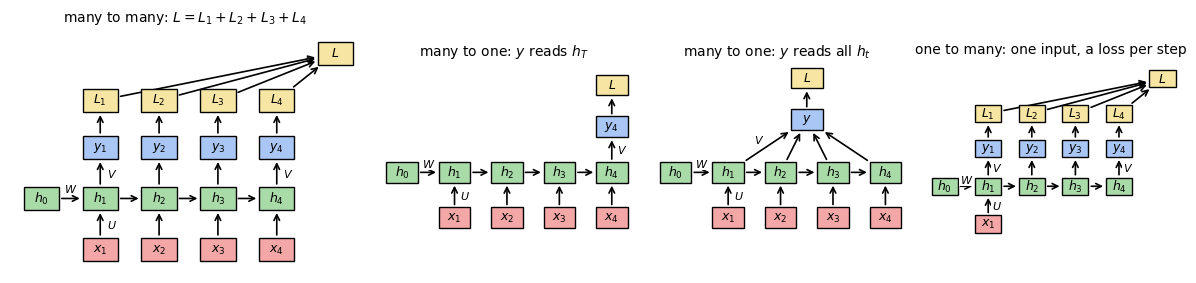

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4.2), gridspec_kw={'width_ratios': [1.35, 1, 1, 1]})
draw_unrolled(axes[0], 4, outputs='all', losses=True, title='many to many: $L = L_1 + L_2 + L_3 + L_4$')
draw_unrolled(axes[1], 4, outputs='last', losses=True, title='many to one: $y$ reads $h_T$')
draw_unrolled(axes[2], 4, outputs='pool', losses=True, title='many to one: $y$ reads all $h_t$')
draw_unrolled(axes[3], 4, outputs='all', losses=True, inputs='first', title='one to many: one input, a loss per step')
plt.tight_layout(); plt.show()

In [19]:
# The gradient of the total loss w.r.t. the shared W is the sum of the per-step gradients.
set_seed(1)
T = 5
xs = torch.randn(T, D, device=device)
targets = torch.randint(0, C, (T,), device=device)
Ug, Wg, Vg = [p.clone().requires_grad_(True) for p in (U, W, V)]

def step_losses(xs, targets, U, W, V):
    """Run the recurrence and return the per-step cross-entropy losses L_t (the many-to-many graph)."""
    hs, ys = rnn_forward(xs, U, W, V)
    return torch.stack([-torch.log(ys[t, targets[t]]) for t in range(T)])

# (i) one backward pass through the whole unrolled graph
Ls = step_losses(xs, targets, Ug, Wg, Vg)
Ls.sum().backward()
grad_total = Wg.grad.clone()

# (ii) one backward pass per loss node, then add them up (the sum rule over L_1 ... L_T)
per_step = []
for t in range(T):
    Wg.grad = None
    step_losses(xs, targets, Ug, Wg, Vg)[t].backward()
    per_step.append(Wg.grad.clone())
grad_sum = torch.stack(per_step).sum(0)
assert torch.allclose(grad_total, grad_sum, atol=1e-6), 'dL/dW is not the sum of the per-step gradients'

print(f'per-step losses L_t = {[round(v, 3) for v in Ls.tolist()]},  L = {Ls.sum().item():.4f}')
print(f'|dL_t/dW| per step  = {[round(g.norm().item(), 4) for g in per_step]}   (zero at t = 1 since h_0 = 0; later steps see more of the sequence)')
print(f'max |dL/dW - sum_t dL_t/dW| = {(grad_total - grad_sum).abs().max().item():.2e}')
print('the many-to-one graph keeps only the last term; the one-to-many graph keeps all T with x_2..x_T removed')

per-step losses L_t = [1.5, 1.643, 1.986, 1.734, 1.203],  L = 8.0661
|dL_t/dW| per step  = [0.0, 0.1643, 0.3215, 0.3142, 0.251]   (zero at t = 1 since h_0 = 0; later steps see more of the sequence)
max |dL/dW - sum_t dL_t/dW| = 1.49e-08
the many-to-one graph keeps only the last term; the one-to-many graph keeps all T with x_2..x_T removed


The number of paths can be counted rather than asserted. The `Node` class of section 4 builds the unrolled graph of a scalar RNN ($H = D = 1$, so $u$, $w$ and the read-out $c$ are single numbers): $h_t = \tanh(u x_t + w h_{t-1})$ and $L_t = c\, h_t$. The shared $w$ is a leaf with one edge into every step, so `all_paths(w, L_t)` should find exactly $t$ paths, one per step at which $w$ enters, and the path sum along them should equal the autograd derivative of the same expression written with tensors.

In [20]:
# Count the paths from the shared w to each L_t on a scalar unrolled RNN, and check the path sum against autograd.
set_seed(1)
T = 5
x_vals = np.random.randn(T)
u, w, c = Node(0.8, name='u'), Node(0.6, name='w'), Node(1.5, name='c')
h_prev, L_nodes = Node(0.0, name='h0'), []
for t in range(1, T + 1):
    x_t = Node(x_vals[t - 1], name=f'x{t}')
    h_prev = tanh_n(add(mul(u, x_t, f'ux{t}'), mul(w, h_prev, f'wh{t - 1}'), f'pre{t}'), f'h{t}')
    L_nodes.append(mul(h_prev, c, f'L{t}'))

n_paths = [len(all_paths(w, L_t)) for L_t in L_nodes]
print(f'number of paths from w to L_t, t = 1..{T}: {n_paths}   (w enters at steps 1..t, so t paths to L_t)')
assert n_paths == list(range(1, T + 1)), 'path count disagrees with the argument'

# The same scalar RNN with tensors: the path sum must equal autograd's dL_t/dw.
ut, wt, ct = (torch.tensor(v, requires_grad=True) for v in (0.8, 0.6, 1.5))
ht, worst = torch.tensor(0.0), 0.0
for t in range(1, T + 1):
    ht = torch.tanh(ut * float(x_vals[t - 1]) + wt * ht)
    (g_w,) = torch.autograd.grad(ct * ht, wt, retain_graph=True)
    worst = max(worst, abs(path_sum(L_nodes[t - 1], w) - g_w.item()))
assert worst < 1e-5, 'path sum through the unrolled graph disagrees with autograd'   # float32 autograd vs float64 path sum
print(f'path sum dL_t/dw vs autograd over t = 1..{T}: max |difference| = {worst:.2e}')
print(f'paths from w to the total loss L = sum_t L_t: {sum(n_paths)} (the sum rule adds the per-step counts)')

number of paths from w to L_t, t = 1..5: [1, 2, 3, 4, 5]   (w enters at steps 1..t, so t paths to L_t)
path sum dL_t/dw vs autograd over t = 1..5: max |difference| = 1.90e-07
paths from w to the total loss L = sum_t L_t: 15 (the sum rule adds the per-step counts)


## 7. Many-to-one in practice: a sequence classifier

Time to train one. The task is chosen so that **order matters**: a sequence of $T$ binary tokens is labelled 1 if it contains the pattern `1, 0, 1` at three consecutive positions and 0 otherwise. A model that only counts the ones cannot solve this, because `1 0 1 0 0` and `1 1 0 0 0` have the same counts and different labels; a model that reads the tokens in order can. The classes are balanced by rejection sampling, so chance is 50 percent.

The model is the many-to-one graph of section 6: `nn.RNN` reads the one-hot tokens, and a linear layer on the **last** hidden state $h_T$ scores the two classes. Three competitors are trained at $T = 16$ for the same number of steps:

1. an **order-blind** logistic regression on the count of ones (what a bag-of-tokens model sees),
2. an **MLP on the concatenated sequence** (order-aware, but its size depends on $T$, section 3.b),
3. the **RNN** with hidden size 16.

In [21]:
def make_pattern_dataset(n, T, pattern=(1, 0, 1), seed=0):
    """n balanced binary sequences of length T; label 1 iff the pattern occurs at consecutive positions.
    Sequences are generated at random and the two classes subsampled to n/2 each."""
    g = torch.Generator().manual_seed(seed)
    pool = torch.randint(0, 2, (n * 40, T), generator=g)
    k = 2.0 * torch.tensor(pattern, dtype=torch.float32) - 1.0        # +-1 kernel: a window matches iff
    resp = F.conv1d((2.0 * pool.float() - 1.0)[:, None, :], k[None, None, :])[:, 0]   # its response is len(pattern)
    has = (resp == len(pattern)).any(1)
    pos, neg = pool[has][: n // 2], pool[~has][: n // 2]
    X = torch.cat([pos, neg]); y = torch.cat([torch.ones(len(pos)), torch.zeros(len(neg))]).long()
    perm = torch.randperm(len(X), generator=g)
    return X[perm].to(device), y[perm].to(device), has.float().mean().item()

Xtr, ytr, frac = make_pattern_dataset(1024, 16, seed=0)
Xte, yte, _ = make_pattern_dataset(1024, 16, seed=100)
print(f'train {tuple(Xtr.shape)}, test {tuple(Xte.shape)}, class balance {ytr.float().mean():.2f}, '
      f'fraction of random length-16 sequences containing 1,0,1: {frac:.2f}')
for i in range(4):
    print(f"  {''.join(str(v) for v in Xtr[i].tolist())}  ->  label {ytr[i].item()}")

class SeqClassifier(nn.Module):
    """Many-to-one: nn.RNN over one-hot tokens, a linear head on the last hidden state."""
    def __init__(self, hidden, n_tokens=2, n_classes=2):
        super().__init__()
        self.rnn = nn.RNN(n_tokens, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_classes)
    def forward(self, tokens):
        x = F.one_hot(tokens, 2).float()                 # (B, T, 2)
        _, h_last = self.rnn(x)                          # h_last: (1, B, hidden)
        return self.head(h_last[0])

def train_model(model, Xtr, ytr, Xte, yte, steps=400, lr=0.01, seed=0, log_every=0):
    """Full-batch Adam on the cross-entropy, with the gradient norm clipped at 1 (the usual guard
    against the occasional huge gradient of an RNN); returns (test accuracy, train accuracy, loss curve)."""
    set_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    curve = []
    for step in range(steps):
        loss = F.cross_entropy(model(Xtr), ytr)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        curve.append(loss.item())
        if log_every and (step % log_every == 0 or step == steps - 1):
            print(f'    step {step:3d}  loss {loss.item():.4f}')
    with torch.no_grad():
        acc_te = (model(Xte).argmax(1) == yte).float().mean().item()
        acc_tr = (model(Xtr).argmax(1) == ytr).float().mean().item()
    return acc_te, acc_tr, curve

train (1024, 16), test (1024, 16), class balance 0.50, fraction of random length-16 sequences containing 1,0,1: 0.82
  1010101100010111  ->  label 1
  1010111110011101  ->  label 1
  1111100000001110  ->  label 0
  1101101001011111  ->  label 1


count of ones (order-blind)  params     6   train acc 0.682   test acc 0.649
MLP on concatenation         params  1122   train acc 1.000   test acc 0.816


RNN, hidden 16               params   354   train acc 0.987   test acc 0.958

(1.3 s for the three runs)


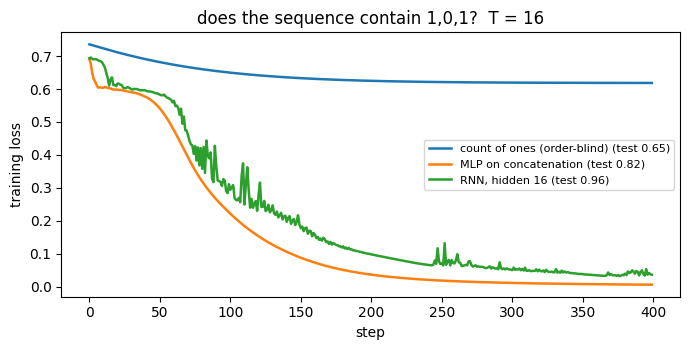

In [22]:
# Three models on the T = 16 task, same optimiser, same number of steps.
class CountModel(nn.Module):
    """Order-blind: logistic regression on the number of ones (and its square)."""
    def __init__(self):
        super().__init__(); self.lin = nn.Linear(2, 2)
    def forward(self, tokens):
        c = tokens.float().sum(1, keepdim=True) / tokens.shape[1]
        return self.lin(torch.cat([c, c ** 2], 1))

class ConcatMLP(nn.Module):
    """Order-aware but fixed-size: an MLP on the T one-hot tokens concatenated into one vector."""
    def __init__(self, T, hidden=32):
        super().__init__(); self.net = nn.Sequential(nn.Linear(2 * T, hidden), nn.Tanh(), nn.Linear(hidden, 2))
    def forward(self, tokens):
        return self.net(F.one_hot(tokens, 2).float().flatten(1))

t0 = time.time()
results = {}
for name, make in [('count of ones (order-blind)', CountModel),
                   ('MLP on concatenation', lambda: ConcatMLP(16)),
                   ('RNN, hidden 16', lambda: SeqClassifier(16))]:
    set_seed(0)
    model = make().to(device)
    acc_te, acc_tr, curve = train_model(model, Xtr, ytr, Xte, yte, steps=400)
    results[name] = (acc_te, acc_tr, curve, count_params(model))
    print(f'{name:28s} params {count_params(model):5d}   train acc {acc_tr:.3f}   test acc {acc_te:.3f}')
print(f'\n({time.time() - t0:.1f} s for the three runs)')

fig, ax = plt.subplots(figsize=(7, 3.6))
for name, (acc_te, _, curve, _) in results.items():
    ax.plot(curve, lw=1.8, label=f'{name} (test {acc_te:.2f})')
ax.set_xlabel('step'); ax.set_ylabel('training loss'); ax.legend(fontsize=8)
ax.set_title('does the sequence contain 1,0,1?  T = 16'); plt.tight_layout(); plt.show()

The order-blind model is stuck a little above chance (0.65), because the count of ones correlates weakly with the label but cannot decide it. The two order-aware models separate in an instructive way. The MLP on the concatenation fits the 1,024 training sequences perfectly and generalises to only 0.82 on fresh ones: with 1,122 weights spread over $2T \times 32$ position-specific connections it can memorise which training sequences were positive without learning the pattern once. The RNN, with 354 weights and one detector applied at every position, reaches 0.96 on the test set. That is weight sharing across time doing its job, and it has the added benefit that the RNN's size is fixed while the MLP's first layer has to be rebuilt for every $T$.

### 7.a Accuracy against sequence length and hidden size

The brief experiment above used one length and one hidden size. The cell below trains the RNN over a grid of lengths $T \in \{6, 10, 16, 24\}$ and hidden sizes $H \in \{2, 4, 8, 16, 32\}$, with a fresh dataset for each $T$, and stores every accuracy (twenty tiny trainings, timed). Two trends to look for: accuracy rises with $H$ until the state is large enough to remember "have I just seen `1, 0`", and at a fixed $H$ longer sequences are harder, because the model must keep that memory intact while more tokens arrive and the gradient must travel back through more steps to teach it.

T =  6: test accuracy over H = [2, 4, 8, 16, 32]: [0.811, 1.0, 1.0, 1.0, 1.0]   train: [0.842, 1.0, 1.0, 1.0, 1.0]


T = 10: test accuracy over H = [2, 4, 8, 16, 32]: [0.814, 0.963, 0.986, 0.986, 0.988]   train: [0.813, 0.979, 0.998, 1.0, 1.0]


T = 16: test accuracy over H = [2, 4, 8, 16, 32]: [0.757, 0.944, 0.957, 0.952, 0.963]   train: [0.748, 0.948, 0.961, 0.996, 1.0]


T = 24: test accuracy over H = [2, 4, 8, 16, 32]: [0.778, 0.873, 0.908, 0.924, 0.935]   train: [0.788, 0.898, 0.926, 0.969, 1.0]
grid of 20 trainings in 9.7 s


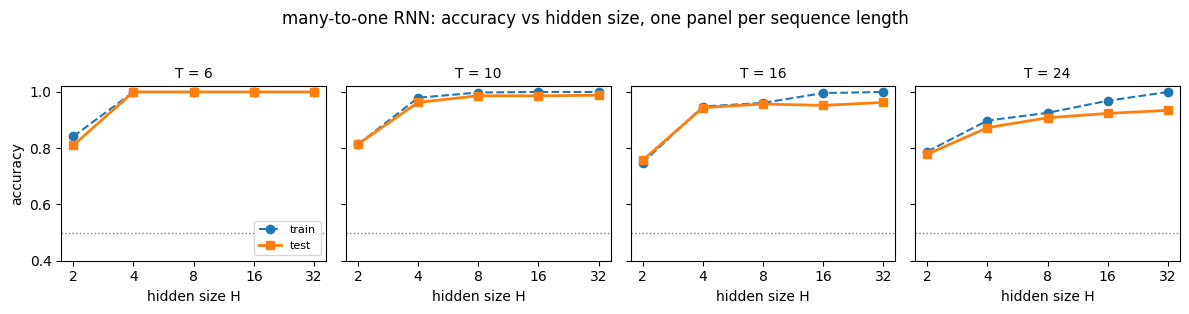

In [23]:
Ts, Hs = [6, 10, 16, 24], [2, 4, 8, 16, 32]
t0 = time.time()
grid_te = np.zeros((len(Ts), len(Hs))); grid_tr = np.zeros_like(grid_te)
for i, T in enumerate(Ts):
    Xtr_T, ytr_T, _ = make_pattern_dataset(1024, T, seed=i)
    Xte_T, yte_T, _ = make_pattern_dataset(1024, T, seed=100 + i)
    for j, Hsz in enumerate(Hs):
        set_seed(0)
        model = SeqClassifier(Hsz).to(device)
        grid_te[i, j], grid_tr[i, j], _ = train_model(model, Xtr_T, ytr_T, Xte_T, yte_T, steps=400)
    print(f'T = {T:2d}: test accuracy over H = {Hs}: {np.round(grid_te[i], 3).tolist()}   '
          f'train: {np.round(grid_tr[i], 3).tolist()}')
print(f'grid of {grid_te.size} trainings in {time.time() - t0:.1f} s')

fig, axes = plt.subplots(1, len(Ts), figsize=(12, 3.0), sharey=True)
for ax, T, row_te, row_tr in zip(axes, Ts, grid_te, grid_tr):
    ax.plot(Hs, row_tr, 'o--', lw=1.5, label='train'); ax.plot(Hs, row_te, 's-', lw=2, label='test')
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.set_xscale('log', base=2); ax.set_xticks(Hs); ax.set_xticklabels(Hs)
    ax.set_xlabel('hidden size H'); ax.set_title(f'T = {T}', fontsize=10); ax.set_ylim(0.4, 1.02)
axes[0].set_ylabel('accuracy'); axes[0].legend(fontsize=8, loc='lower right')
fig.suptitle('many-to-one RNN: accuracy vs hidden size, one panel per sequence length', y=1.03)
plt.tight_layout(); plt.show()

### Widget 3: hidden size versus accuracy

Everything is precomputed; the slider only indexes the grid. Pick a sequence length `T` and read accuracy against hidden size, with the other lengths in grey for comparison. Watch the curve at $H = 2$: two hidden units are not enough at any length, and the gap between train and test accuracy at $H = 32$ grows with $T$.

In [24]:
def grid_widget(T=16):
    i = Ts.index(T)
    fig, ax = plt.subplots(figsize=(7, 3.6))
    for k, T_other in enumerate(Ts):
        if k != i:
            ax.plot(Hs, grid_te[k], '-', color='0.8', lw=1)
    ax.plot(Hs, grid_tr[i], 'o--', lw=1.5, label=f'train, T = {T}')
    ax.plot(Hs, grid_te[i], 's-', lw=2.2, label=f'test, T = {T}')
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.set_xscale('log', base=2); ax.set_xticks(Hs); ax.set_xticklabels(Hs); ax.set_ylim(0.4, 1.02)
    ax.set_xlabel('hidden size H'); ax.set_ylabel('accuracy'); ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f'T = {T}: best test accuracy {grid_te[i].max():.3f} at H = {Hs[int(grid_te[i].argmax())]}')
    plt.tight_layout(); plt.show()

interact(grid_widget, T=Dropdown(options=Ts, value=16, description='T'));

interactive(children=(Dropdown(description='T', index=2, options=(6, 10, 16, 24), value=16), Output()), _dom_c…

## 8. A character-level language model

The slides close with the example from Andrej Karpathy's blog post: a vocabulary `[h, e, l, o]` and the training sequence `hello`. The input at each step is a one-hot vector of length 4, the hidden state has 3 units, and the output layer scores the 4 characters, so with $W_{xh} \in \mathbb{R}^{3\times4}$, $W_{hh} \in \mathbb{R}^{3\times3}$ and $W_{hy} \in \mathbb{R}^{4\times3}$ the whole model has $12 + 9 + 12 = 33$ weights. Training is many-to-many: input `hell`, targets `ello`, one cross-entropy per position. At test time you **sample characters one at a time and feed each output back to the model** as the next input.

### 8.a The `hello` model

In [25]:
# The char-level model from the slides, trained on the single word "hello".
vocab = ['h', 'e', 'l', 'o']
stoi = {c: i for i, c in enumerate(vocab)}
Vsz, Hsz = len(vocab), 3

set_seed(0)
Wxh = (torch.randn(Hsz, Vsz, device=device) * 0.3).requires_grad_(True)
Whh = (torch.randn(Hsz, Hsz, device=device) * 0.3).requires_grad_(True)
Why = (torch.randn(Vsz, Hsz, device=device) * 0.3).requires_grad_(True)
print(f'parameters: {Wxh.numel()} + {Whh.numel()} + {Why.numel()} = {Wxh.numel() + Whh.numel() + Why.numel()} weights')

def onehot(ch):
    v = torch.zeros(Vsz, device=device); v[stoi[ch]] = 1.0; return v

inputs, targets = 'hell', 'ello'
opt = torch.optim.Adam([Wxh, Whh, Why], lr=0.1)
for step in range(300):
    h = torch.zeros(Hsz, device=device); loss = 0.0
    for ch, tgt in zip(inputs, targets):
        h = torch.tanh(Wxh @ onehot(ch) + Whh @ h)
        logits = Why @ h
        loss = loss + F.cross_entropy(logits[None, :], torch.tensor([stoi[tgt]], device=device))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 100 == 0 or step == 299:
        print(f'  step {step:3d}  loss {loss.item():.4f}')
print(f'loss after training: {loss.item():.4f}')

# Sample from the trained model (as the slide says: draw a character, feed it back in as the next input).
set_seed(0)
with torch.no_grad():
    h = torch.zeros(Hsz, device=device)
    ch = 'h'; generated = ch; p_chosen = []
    for _ in range(4):
        h = torch.tanh(Wxh @ onehot(ch) + Whh @ h)
        probs = torch.softmax(Why @ h, dim=0)
        nxt = int(torch.multinomial(probs, 1))          # a draw from the model's distribution, not the arg max
        p_chosen.append(round(probs[nxt].item(), 3))
        ch = vocab[nxt]
        generated += ch
print(f'\nseeded with "h", the model samples: {generated}   (target was hello; probability of each drawn character {p_chosen})')

parameters: 12 + 9 + 12 = 33 weights
  step   0  loss 5.3919
  step 100  loss 0.0110
  step 200  loss 0.0049


  step 299  loss 0.0028
loss after training: 0.0028

seeded with "h", the model samples: hello   (target was hello; probability of each drawn character [0.999, 1.0, 1.0, 0.999])


### 8.b A paragraph of text

Four characters do not make a language model. The same recipe on a paragraph (stored right here in the notebook, so nothing is downloaded) gives a model that has to learn spelling, spacing and some phrase structure from about 1,200 characters. The model is `nn.RNN` with a hidden size of 128 over one-hot characters, trained on random 40-character windows; the loss is the average cross-entropy per character, so $\log(29) \approx 3.37$ is the loss of guessing uniformly over the 29 symbols.

In [26]:
TEXT = (
    "a recurrent neural network reads a sequence one element at a time. at each step it "
    "combines the new input with its hidden state, using the same weights it used at every "
    "earlier step. the hidden state is the memory of the network: it records what the network "
    "has seen so far, and it is morphed a little by each new input. because the weights are "
    "shared across time, one small model can read a sequence of any length. to train it, we "
    "unroll the network in time, sum the losses of every step, and backpropagate through the "
    "unrolled graph. a feedforward network cannot do this: it takes an input of fixed size and "
    "treats every input as independent of the last. a convolutional network fed two images in a "
    "row computes two answers that know nothing about each other. sequence learning problems are "
    "different. the inputs depend on each other, the number of inputs and the number of predictions "
    "are not fixed, and the same task is performed at every position: read a character, predict the "
    "next character. the shapes differ from task to task. captioning maps one image to many words. "
    "action recognition maps many frames to one label. tagging maps every word to a tag. in all of "
    "them the recurrence is the same, only where you read the outputs changes. "
)
chars = sorted(set(TEXT)); V_text = len(chars)
ctoi = {c: i for i, c in enumerate(chars)}
data = torch.tensor([ctoi[c] for c in TEXT], device=device)
print(f'{len(TEXT)} characters, vocabulary of {V_text}: {"".join(chars)!r}')
print(f'uniform-guess loss log({V_text}) = {math.log(V_text):.3f}')

class CharRNN(nn.Module):
    """One-hot characters -> nn.RNN -> a score per character at every step (many-to-many)."""
    def __init__(self, V, hidden):
        super().__init__()
        self.V = V
        self.rnn = nn.RNN(V, hidden, batch_first=True)
        self.head = nn.Linear(hidden, V)
    def forward(self, idx, h=None):
        x = F.one_hot(idx, self.V).float()
        hs, h = self.rnn(x, h)
        return self.head(hs), h

def random_windows(batch, L, g):
    """batch windows of L characters and their targets shifted by one."""
    starts = torch.randint(0, len(data) - L - 1, (batch,), generator=g)
    X = torch.stack([data[s:s + L] for s in starts])
    Y = torch.stack([data[s + 1:s + L + 1] for s in starts])
    return X, Y

set_seed(0)
g_win = torch.Generator().manual_seed(0)
char_model = CharRNN(V_text, 128).to(device)
opt = torch.optim.Adam(char_model.parameters(), lr=5e-3)
t0 = time.time(); char_curve = []
for step in range(500):
    X, Y = random_windows(32, 40, g_win)
    logits, _ = char_model(X)
    loss = F.cross_entropy(logits.reshape(-1, V_text), Y.reshape(-1))
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(char_model.parameters(), 1.0)    # keeps the early steps stable
    opt.step(); char_curve.append(loss.item())
    if step % 100 == 0 or step == 499:
        print(f'  step {step:3d}  loss per character {loss.item():.3f}')
print(f'{count_params(char_model)} parameters, trained in {time.time() - t0:.1f} s')

1245 characters, vocabulary of 29: ' ,.:abcdefghiklmnopqrstuvwxyz'
uniform-guess loss log(29) = 3.367
  step   0  loss per character 3.383


  step 100  loss per character 1.130


  step 200  loss per character 0.387


  step 300  loss per character 0.264


  step 400  loss per character 0.209


  step 499  loss per character 0.202
24093 parameters, trained in 1.2 s


### 8.c Sampling with a temperature

At test time the model is run one character at a time. With scores $s$ for the next character, sampling from $\mathrm{softmax}(s / \tau)$ with a **temperature** $\tau$ controls how adventurous the model is: $\tau \to 0$ always picks the arg max (and tends to fall into loops of memorised phrases), $\tau = 1$ samples from the model's own distribution, and $\tau > 1$ flattens the distribution toward uniform, which quickly produces noise. The from-scratch softmax with temperature is checked against `torch.softmax`, and the figure shows the next-character distribution after the seed `the network` at four temperatures, followed by a sample at each.

from-scratch temperature softmax matches torch.softmax(scores / tau)


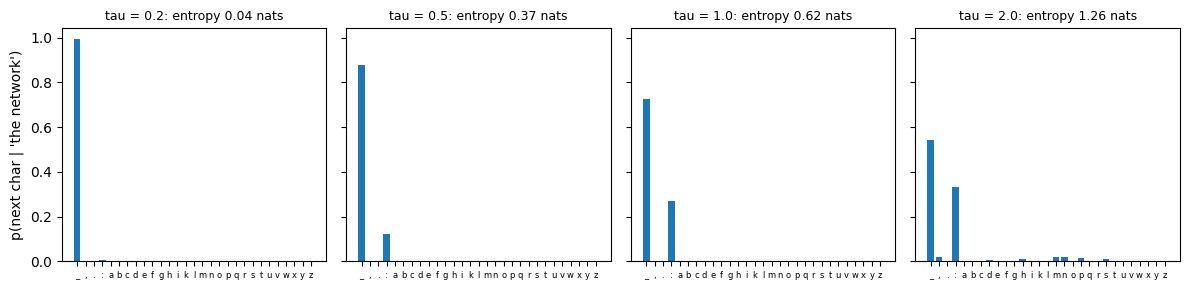

tau = 0.2: 'the network has seen so far, and it is morphed a little by each new input. because the weights are shared across time, on'
tau = 0.5: 'the network has seen so far, and it is morphed a little by each new input. because the weights are shared across time, on'
tau = 1.0: 'the network has the nutber uiffra to t tedect the number of inputs and the number of predictions are not fixed, and the s'
tau = 2.0: 'the network has thevg.tha liofads. b combureat e cmary done l tigh the himbineutiffe, ue character.cth tsea: ct phed f de'


In [27]:
def softmax_temperature(scores, tau):
    """p_i proportional to exp(s_i / tau), computed stably from scratch."""
    z = scores / tau
    z = z - z.max()
    e = torch.exp(z)
    return e / e.sum()

def sample_text(model, seed_text, n_chars, tau, seed=1):
    """Feed the seed, then sample one character at a time, feeding each choice back in."""
    set_seed(seed)
    idx = torch.tensor([ctoi[c] for c in seed_text], device=device)
    out = seed_text
    with torch.no_grad():
        logits, h = model(idx[None])
        for _ in range(n_chars):
            p = softmax_temperature(logits[0, -1], tau)
            nxt = torch.multinomial(p, 1)
            out += chars[nxt.item()]
            logits, h = model(nxt[None], h)
    return out

def next_char_distribution(model, seed_text):
    with torch.no_grad():
        logits, _ = model(torch.tensor([ctoi[c] for c in seed_text], device=device)[None])
    return logits[0, -1]

scores = next_char_distribution(char_model, 'the network')
assert torch.allclose(softmax_temperature(scores, 0.7), torch.softmax(scores / 0.7, 0), atol=1e-6)
print('from-scratch temperature softmax matches torch.softmax(scores / tau)')

taus = [0.2, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.0), sharey=True)
for ax, tau in zip(axes, taus):
    p = softmax_temperature(scores, tau).detach().cpu().numpy()
    ax.bar(range(V_text), p, color='tab:blue')
    ax.set_xticks(range(V_text)); ax.set_xticklabels([c if c != ' ' else '_' for c in chars], fontsize=6)
    ax.set_title(f'tau = {tau}: entropy {-(p * np.log(p + 1e-12)).sum():.2f} nats', fontsize=9)
axes[0].set_ylabel("p(next char | 'the network')")
plt.tight_layout(); plt.show()

for tau in taus:
    print(f'tau = {tau}: {sample_text(char_model, "the network", 110, tau)!r}')

### Widget 4: sampling temperature

Drag `tau`. Low values replay the training text almost verbatim (the model has nearly memorised the paragraph); around 1 the phrases recombine into new, mostly well-spelled sentences; above 1.5 the distribution flattens and the spelling falls apart. The seed can be any string made of characters in the vocabulary.

In [28]:
def temperature_widget(tau=1.0, seed_text='the network'):
    if any(c not in ctoi for c in seed_text):
        print('the seed may only use characters from the vocabulary'); return
    scores = next_char_distribution(char_model, seed_text)
    p = softmax_temperature(scores, tau).detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.bar(range(V_text), p, color='tab:blue')
    ax.set_xticks(range(V_text)); ax.set_xticklabels([c if c != ' ' else '_' for c in chars], fontsize=7)
    ax.set_ylabel('p(next char)'); ax.set_title(f"next character after {seed_text!r} at tau = {tau:.2f}")
    plt.tight_layout(); plt.show()
    print(sample_text(char_model, seed_text, 160, tau))

interact(temperature_widget, tau=FloatSlider(min=0.1, max=2.5, step=0.1, value=1.0, continuous_update=False),
         seed_text=widgets.Text(value='the network', description='seed'));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='tau', max=2.5, min=0.1), Te…

## 9. The slide's homework, answered

The last slide leaves two questions. The next lecture's review slide gives the short answers; here they are, with measurements.

### 9.a Can RNNs have more than one hidden layer?

> "Yes. You can also have multiple RNN blocks; these are called stacked RNNs."

A **stacked RNN** feeds the hidden-state sequence of layer 1 as the input sequence of layer 2: $h^{(1)}_t = \tanh(U_1 x_t + W_1 h^{(1)}_{t-1})$, then $h^{(2)}_t = \tanh(U_2 h^{(1)}_t + W_2 h^{(2)}_{t-1})$, and the output is read from the top layer. Every layer still shares its weights across time, so the parameter count grows with the number of layers but not with $T$. The cell stacks two copies of our loop and checks the result against `nn.RNN(num_layers=2)`.

In [29]:
def stacked_rnn_forward(xs, layers):
    """A stacked RNN: layers is a list of (U, W) pairs; each layer reads the previous layer's hidden sequence."""
    seq = xs
    all_hs = []
    for U_l, W_l in layers:
        h = torch.zeros(U_l.shape[0], device=xs.device)
        hs = []
        for x in seq:
            h = torch.tanh(U_l @ x + W_l @ h)
            hs.append(h)
        seq = torch.stack(hs)                # the next layer's input sequence
        all_hs.append(seq)
    return all_hs

set_seed(0)
ref2 = nn.RNN(D, H, num_layers=2, bias=False, batch_first=True).to(device)
layers = [(ref2.weight_ih_l0.detach(), ref2.weight_hh_l0.detach()),
          (ref2.weight_ih_l1.detach(), ref2.weight_hh_l1.detach())]
xs = torch.randn(7, D, device=device)
h1, h2 = stacked_rnn_forward(xs, layers)
theirs, h_last2 = ref2(xs[None])
assert torch.allclose(h2, theirs[0], atol=1e-6), 'stacked loop disagrees with nn.RNN(num_layers=2)'
assert torch.allclose(torch.stack([h1[-1], h2[-1]]), h_last2[:, 0], atol=1e-6)
print(f'two stacked loops vs nn.RNN(num_layers=2): max |difference| = {(h2 - theirs[0]).abs().max().item():.2e}')
print(f'layer-1 states {tuple(h1.shape)} feed layer 2, whose states are {tuple(h2.shape)}')
for L in (1, 2, 3):
    m = nn.RNN(D, H, num_layers=L, bias=False)
    print(f'  num_layers = {L}: {count_params(m):3d} parameters  (layer 1: {D * H + H * H}, each extra layer: {H * H + H * H})')

two stacked loops vs nn.RNN(num_layers=2): max |difference| = 5.96e-08
layer-1 states (7, 3) feed layer 2, whose states are (7, 3)
  num_layers = 1:  21 parameters  (layer 1: 21, each extra layer: 18)
  num_layers = 2:  39 parameters  (layer 1: 21, each extra layer: 18)
  num_layers = 3:  57 parameters  (layer 1: 21, each extra layer: 18)


### 9.b What if we morph the state too much?

> "The state $h_t$ of an RNN records information from all previous time steps. At each new timestep, the old information gets morphed slightly by the current input. What would happen if we morphed the state too much?"

The review slide's answer: *the effect of previous time steps would be reduced, which may not be desirable for sequence learning problems*. To measure it, start the same recurrence from **two different initial states** $h_0$ and $h_0'$, feed both the **same** input sequence, and track the distance $\|h_t - h_t'\|$ over time. That distance is exactly how much the past still matters at step $t$: if it stays large, the state remembers where it came from; if it collapses to zero, the inputs have overwritten the history and the network is effectively feedforward. The knob is the scale of $U$ relative to $W$, the size of the "morph" each input applies. With a large input scale the $\tanh$ saturates at $\pm 1$ in the direction chosen by $x_t$ alone and the two trajectories become identical within a few steps.

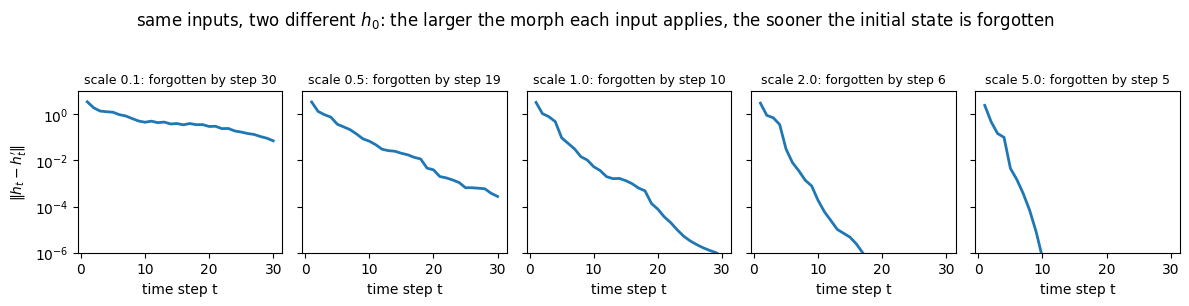

steps until the two initial states are indistinguishable (||h_t - h_t'|| < 0.01):
  scale 0.1: 30   scale 0.5: 19   scale 1.0: 10   scale 2.0: 6   scale 5.0: 5


In [30]:
def divergence_curve(input_scale, w_scale=1.0, steps=30, H=16, D=4, seed=0):
    """||h_t - h_t'|| over time for two different initial states fed the same inputs."""
    set_seed(seed)
    Us = torch.randn(H, D, device=device) * input_scale / math.sqrt(D)
    Ws = torch.randn(H, H, device=device) * w_scale / math.sqrt(H)
    xs = torch.randn(steps, D, device=device)
    h, h2 = torch.randn(H, device=device), torch.randn(H, device=device)
    dists = []
    for x in xs:
        h, h2 = torch.tanh(Us @ x + Ws @ h), torch.tanh(Us @ x + Ws @ h2)
        dists.append((h - h2).norm().item())
    return np.array(dists)

def memory_horizon(dists, tol=1e-2):
    """First step at which the two trajectories are within tol, or the number of steps if never."""
    below = np.nonzero(dists < tol)[0]
    return int(below[0]) + 1 if len(below) else len(dists)

scales = [0.1, 0.5, 1.0, 2.0, 5.0]
fig, axes = plt.subplots(1, len(scales), figsize=(12, 2.9), sharey=True)
for ax, s in zip(axes, scales):
    d = divergence_curve(s)
    ax.semilogy(np.arange(1, len(d) + 1), d, lw=2)
    ax.set_title(f'scale {s}: forgotten by step {memory_horizon(d)}', fontsize=9)
    ax.set_xlabel('time step t'); ax.set_ylim(1e-6, 10)
axes[0].set_ylabel("$\\|h_t - h_t'\\|$")
fig.suptitle("same inputs, two different $h_0$: the larger the morph each input applies, the sooner the initial state is forgotten", y=1.04)
plt.tight_layout(); plt.show()
print('steps until the two initial states are indistinguishable (||h_t - h_t\'|| < 0.01):')
print('  ' + '   '.join(f'scale {s}: {memory_horizon(divergence_curve(s))}' for s in scales))

### Widget 5: how much to morph the state

Drag `input_scale` (the size of each input's morph) and `w_scale` (how strongly the old state is carried forward). With a small input scale and `w_scale` near 1 the two trajectories drift together only slowly and are still apart after 40 steps: the state remembers its origin. Push `input_scale` up and the curve drops off a cliff within a handful of steps. Pushing `w_scale` well below 1 also forgets, for the opposite reason: the old state is shrunk rather than overwritten, which is the effect explored in the last section.

In [31]:
def morph_widget(input_scale=1.0, w_scale=1.0):
    d = divergence_curve(input_scale, w_scale, steps=40)
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.semilogy(np.arange(1, len(d) + 1), d, lw=2)
    ax.set_ylim(1e-6, 10); ax.set_xlabel('time step t'); ax.set_ylabel("$\\|h_t - h_t'\\|$")
    ax.set_title(f'input scale {input_scale:.1f}, W scale {w_scale:.1f}: initial state forgotten by step {memory_horizon(d)}')
    plt.tight_layout(); plt.show()

interact(morph_widget, input_scale=FloatSlider(min=0.1, max=6.0, step=0.1, value=1.0, continuous_update=False),
                       w_scale=FloatSlider(min=0.2, max=2.0, step=0.1, value=1.0, continuous_update=False));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='input_scale', max=6.0, min=…

## 10. Explore and verify

Three claims are worth checking rather than trusting: that our hand-written loop is exactly what `nn.RNN` computes (once more, at a different length and seed), that the parameter count really is independent of sequence length, and that the sum-over-paths rule holds on an expression with more paths than the slide's. The slides also contain a softmax column that does not match its logits, which is worth recomputing.

In [32]:
# 1. Our loop == nn.RNN at a new length and seed.
set_seed(3)
ref = nn.RNN(input_size=D, hidden_size=H, nonlinearity='tanh', bias=False, batch_first=True).to(device)
with torch.no_grad():
    ref.weight_ih_l0.copy_(U); ref.weight_hh_l0.copy_(W)
xs_test = torch.randn(12, D, device=device)
ours, _ = rnn_forward(xs_test, U, W, V)
theirs, _ = ref(xs_test[None])
assert torch.allclose(ours, theirs[0], atol=1e-6), 'hand-written loop disagrees with nn.RNN'

# 2. Parameter count does not grow with T.
counts = {T: count_params(nn.RNN(D, H, bias=False)) for T in (10, 100, 1000)}
assert len(set(counts.values())) == 1, 'parameter count changed with sequence length'

# 3. Sum over paths on a bigger graph: f = (a*b + tanh(a + b)) * (b + 1), three paths from b to f (and two from a).
def build_bigger(av, bv):
    a, b = Node(av, name='a'), Node(bv, name='b')
    f = mul(add(mul(a, b, 'ab'), tanh_n(add(a, b, 'a+b'), 'tanh'), 'sum'), add_c(b, 1.0, 'b+1'), 'f')
    return a, b, f
a_n, b_n, f_n = build_bigger(0.7, -0.4)
ta, tb = torch.tensor(0.7, requires_grad=True), torch.tensor(-0.4, requires_grad=True)
((ta * tb + torch.tanh(ta + tb)) * (tb + 1)).backward()
assert abs(path_sum(f_n, a_n) - ta.grad.item()) < 1e-6 and abs(path_sum(f_n, b_n) - tb.grad.item()) < 1e-6
assert abs(backward(f_n)['b'] - tb.grad.item()) < 1e-6

# 4. The slides' first softmax column. Recompute it.
logits = torch.tensor([1.0, 2.2, -3.0, 4.1])
slide  = torch.tensor([0.03, 0.84, 0.00, 0.13])
actual = torch.softmax(logits, dim=0)

print(f'  loop vs nn.RNN, max |difference| = {(ours - theirs[0]).abs().max().item():.2e}')
print(f'  parameters at T = 10/100/1000   = {list(counts.values())}')
print(f'  paths from a to f: {len(all_paths(a_n, f_n))}, from b to f: {len(all_paths(b_n, f_n))}; '
      f'path sum df/db = {path_sum(f_n, b_n):.4f}, autograd {tb.grad.item():.4f}')
print(f'\n  logits            {[round(v, 2) for v in logits.tolist()]}')
print(f'  slide prints      {[round(v, 2) for v in slide.tolist()]}')
print(f'  actual softmax    {[round(v, 2) for v in actual.tolist()]}')
print('  -> the slide column is permuted; the largest logit (4.1) must get the largest probability')

  loop vs nn.RNN, max |difference| = 8.94e-08
  parameters at T = 10/100/1000   = [21, 21, 21]
  paths from a to f: 2, from b to f: 3; path sum df/db = 0.9804, autograd 0.9804

  logits            [1.0, 2.2, -3.0, 4.1]
  slide prints      [0.03, 0.84, 0.0, 0.13]
  actual softmax    [0.04, 0.13, 0.0, 0.84]
  -> the slide column is permuted; the largest logit (4.1) must get the largest probability


The last experiment closes the loop with the homework. Section 9 forgot the past by overwriting it with large inputs; the other way to lose it is through $W$ itself. With **no inputs at all**, the state evolves as $h_t = \tanh(W h_{t-1})$ and its norm tells you what the recurrence does to whatever it is asked to remember: a small $W$ shrinks the state to nothing within a few steps, a large one drives it into the saturated corners of the $\tanh$ where every state looks alike. Only a narrow band of scales keeps a usable memory, which is the problem the rest of this week addresses.

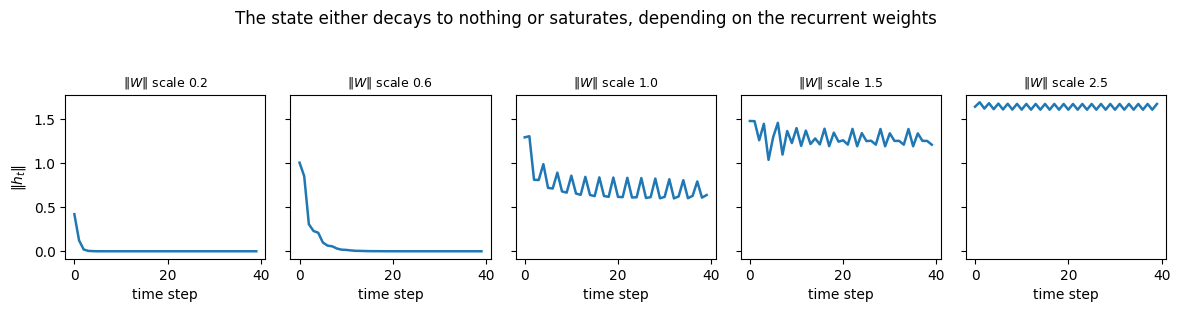

In [33]:
# Static sweep: how fast does the hidden state forget its initial value?
fig, ax = plt.subplots(1, 5, figsize=(12, 2.9), sharey=True)
for a, scale in zip(ax, [0.2, 0.6, 1.0, 1.5, 2.5]):
    set_seed(0)
    Ws = torch.randn(H, H, device=device) * scale
    h = torch.ones(H, device=device)
    norms = []
    for t in range(40):
        h = torch.tanh(Ws @ h)
        norms.append(h.norm().item())
    a.plot(norms, lw=1.8)
    a.set_title(f'$\\|W\\|$ scale {scale}', fontsize=9)
    a.set_xlabel('time step')
ax[0].set_ylabel('$\\|h_t\\|$')
fig.suptitle('The state either decays to nothing or saturates, depending on the recurrent weights', y=1.06)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [34]:
# Live: the scale of W decides whether memory decays or saturates.
def memory(scale=1.0, steps=40):
    set_seed(0)
    Ws = torch.randn(H, H, device=device) * scale
    h = torch.ones(H, device=device)
    norms = []
    for _ in range(steps):
        h = torch.tanh(Ws @ h)
        norms.append(h.norm().item())
    fig, a = plt.subplots(figsize=(7, 3.2))
    a.plot(norms, lw=2)
    a.set_xlabel('time step'); a.set_ylabel('$\\|h_t\\|$')
    a.set_title(f'recurrent weight scale = {scale:.2f}')
    plt.tight_layout(); plt.show()

interact(memory, scale=FloatSlider(min=0.1, max=3.0, step=0.1, value=1.0),
                 steps=IntSlider(min=10, max=100, step=10, value=40));

interactive(children=(FloatSlider(value=1.0, description='scale', max=3.0, min=0.1), IntSlider(value=40, descr…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Sequence problems** | Inputs are dependent, of variable length, and the same task runs at every position; a fixed-size, order-blind layer fits none of the three |
| **Internal state** | $h_t = f_{UW}(x_t, h_{t-1})$: the state carries everything the model remembers about $x_1, \dots, x_{t-1}$ |
| **Simple RNN** | $h_t = \tanh(Ux_t + Wh_{t-1})$, $y_t = \mathrm{softmax}(Vh_t)$; also called vanilla or Elman; identical to `nn.RNN(bias=False)` |
| **Weight sharing** | One set of $U, W, V$ is reused at every step, so the parameter count (33 here) is independent of $T$, while an MLP on the concatenation needs $12T + 12$ |
| **Computational graph** | Nodes are operations and variables, edges carry tensors and local derivatives; forward evaluates, backward differentiates |
| **Sum over paths** | $\partial e / \partial b = 1 \cdot 2 + 1 \cdot 3 = 5$: sum over paths of the product of edge derivatives; reverse mode gets every node's gradient in one sweep |
| **Autograd** | The graph is built on the go during the forward pass (`grad_fn`), gradients are computed when `backward()` is called |
| **Unrolled RNN** | $W$ feeds every step, so $\partial L/\partial W = \sum_t \partial L_t/\partial W$ and the number of paths grows with $T$ |
| **Many-to-one** | An order-blind model stays at 0.65 on the `1, 0, 1` task and a fixed-size MLP memorises it; the RNN generalises, and needs a larger $H$ as $T$ grows |
| **Char-level LM** | One-hot in, softmax out, sample and feed back; the temperature $\tau$ trades verbatim replay against noise |
| **Homework** | Stacked RNNs are fine (`num_layers=2` adds $H^2 + H^2$ weights); morphing the state too much erases the earlier time steps within a few steps |

**The shapes at a glance**

| Shape | Inputs fed | Outputs read | Loss nodes | Example in this notebook |
|---|---|---|---|---|
| one to one | 1 | 1 | 1 | a plain classifier, no recurrence |
| one to many | $x_1$ only | every step | $L_1 \dots L_T$ | the encoded image as $x_1$ (section 3.d) |
| many to one | every step | last step | $L_T$ | the `1, 0, 1` detector (section 7) |
| many to many | every step | every step | $L_1 \dots L_T$, summed | the character models (section 8) |

## Exercises

1. **The homework from the slides.** (a) Can an RNN have more than one hidden layer? Stack a third recurrence on top of the two in section 9.a and verify against `nn.RNN(num_layers=3)`; report the parameter count. (b) What happens if the state is morphed too much? Use `divergence_curve` to find the smallest `input_scale` at which the initial state is forgotten within 5 steps. *(From our runs: three layers of hidden size 3 have 57 weights, 21 for the first layer and 9 + 9 for each extra layer; at `w_scale = 1` the two initial states were still distinguishable after 30 steps at input scale 0.1, and were forgotten by step 19, 10, 6 and 5 at input scales 0.5, 1, 2 and 5; on a 0.1 grid the threshold is `input_scale = 4.2`: the horizon stays at 6 steps from 1.9 to 4.1 and drops to 5 at 4.2.)*
2. **Make the task harder.** Change `pattern` in `make_pattern_dataset` to a four-token pattern such as `(1, 1, 0, 1)` and rerun the grid of section 7.a. Report which hidden sizes still reach 95 percent test accuracy at $T = 16$, and whether the count-of-ones baseline moves at all.
3. **Fix the slide.** Recompute all four softmax columns of the character-level example and identify which ones do not match what is printed. What is the giveaway, without doing any arithmetic? *(The largest logit in a column must receive the largest probability. Two columns are wrong, the first and the second: for logits $[1.0, 2.2, -3.0, 4.1]$ the softmax is $[.04, .13, .00, .84]$, not the printed $[.03, .84, .00, .13]$, and for $[0.5, 0.3, -1.0, 1.2]$ it is $[.247, .202, .055, .497]$, not the printed $[.25, .20, .50, .05]$: the first printed column has its second and fourth entries swapped, the second its third and fourth. Columns three and four match.)*
4. **A colder and a hotter model.** Retrain the paragraph model of section 8.b with hidden size 32 and with 1,500 steps instead of 500, and compare the samples at $\tau = 1$. Which change makes the samples more original, and which makes them closer to verbatim? Use the loss per character to explain the difference.
5. **One-to-many, properly.** The captioning trace in section 3.d feeds zeros after the first step. Change it to feed the previous *output* back in as the next input, as the sampler in section 8 does, and describe how that changes what the model can generate.
6. **Count the paths.** Extend `build_bigger` so that $b$ is used three times, print `len(all_paths(b, f))`, and time `path_sum` against `backward` as the expression grows. At what size does enumerating paths become impractical, and why does reverse mode not suffer from it?